# Import

In [21]:
import re
import ast
import time
import pandas as pd
from openai import OpenAI
import yaml
import os
import json
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
)
import numpy as np
from bidi.algorithm import get_display

# Configuration

In [22]:
config_path = os.path.join('..', 'config', 'config.yaml')
PARAMS = yaml.safe_load(open(config_path, 'r', encoding='utf-8'))

TYPES = PARAMS['TYPES']
TYPES = ['drugs','weapon'] 

# Base paths (without {type} placeholder - will be formatted per type)
CSV_PATH_TEMPLATE = os.path.join('..', PARAMS['CSV_PATH'])  # '../cases_csv/{type}'
RESULTS_PATH = os.path.join('..', PARAMS['RESULTS_PATH'])
GT_PATH = os.path.join('..', PARAMS['GT_PATH'])

# Helper function to get path for specific type
def get_csv_path(type_name):
    return CSV_PATH_TEMPLATE.format(type=type_name)

def get_results_path(type_name, subdir=None):
    if subdir:
        return os.path.join(RESULTS_PATH, type_name, subdir)
    return os.path.join(RESULTS_PATH, type_name)

client = OpenAI(api_key=PARAMS['OPENAI_API_KEY'])

ALLOWED = {
    "עובדות המקרה",
    "ראיות לעונש",
    "טיעוני הצדדים",
    "תסקיר שירות מבחן",
    "דיון והכרעה",
    "מידע אחר",
}

# Prompts

In [23]:
SYSTEM_PROMPT= """
אתה מומחה לסיווג טקסטים משפטיים מפסקי דין ישראליים.

אתה מקבל כקלט את *כל* פסקי הדין במבנה הבא:
- כותרת (שורה בפני עצמה)
- אחריה מספר פסקאות ממוספרות כך:   <מספר>( <טקסט הפסקה>
- לאחר מכן כותרת נוספת ופסקאות נוספות, וכן הלאה.

עליך לזהות:
1. מהי הכותרת של כל קבוצת פסקאות
2. מהו הטקסט של כל פסקה
3. ולסווג **כל פסקה לפי מספרה** לאחת מהקטגוריות הבאות:

1. עובדות המקרה  
2. ראיות לעונש  
3. טיעוני הצדדים  
4. תסקיר שירות מבחן  
5. דיון והכרעה  
6. מידע אחר  

────────────────────────────────────────

## כללי רצף בין קטגוריות (חשוב מאוד!)

המבנה התקין של פסק דין הוא:

1. מידע אחר (אופציונלי)
2. עובדות המקרה
3. ראיות לעונש / טיעוני הצדדים / תסקיר שירות מבחן (כל סדר)
4. דיון והכרעה
5. מידע אחר (למשל זכות ערעור)

**אסור לחזור אחורה!**

לדוגמה:
- אם פסקה 5 מסווגת כ"דיון והכרעה" — פסקה 6 לא יכולה להיות “טיעוני הצדדים”.
- אם עברנו מעובדות המקרה לטיעוני הצדדים — אין לחזור לעובדות המקרה.

────────────────────────────────────────

להלן המדריך המלא לסיווג:

────────────────────────────────────────
1. **עובדות המקרה**
תיאור עובדתי של האירוע והנסיבות: מה קרה, כיצד, באילו עבירות הואשם/הודה הנאשם, רקע, מבוא, השתלשלות עניינים, עובדות כתב האישום, וכן פרטים מתוך הסדר טיעון.
**מילות מפתח חזקות:** "כתב האישום", "העובדות", "כללי", "פתח דבר", "עבירה", "רקע", "מבוא", "השתלשלות", "על פי עובדות האישום", "הסדר טיעון", "עובדות כתב האישום".
**הערות:**
- "הסדר טיעון" מסווג כמעט תמיד כאן (אלא אם הכותרת מתמקדת בטענות).
- אם מופיעות טענות ברורות של צדדים → שקול "טיעוני הצדדים".

────────────────────────────────────────
2. **ראיות לעונש**
כל מידע שמוגש לבית המשפט לצורך קביעת העונש: עבר פלילי, חוות דעת, עדי אופי, מסמכים, נתוני תעסוקה, נסיבות חיים בהקשר ראייתי.
**מילות מפתח:** "ראיות לעונש", "הרשעות קודמות", "עבר פלילי", "חוות דעת", "מכתבים", "מסמכים", "תעסוקה", "מוצגים".
**הערה:** אם הכותרת עוסקת בראיה עצמה – ולא בטענות – היא משתייכת לכאן.

────────────────────────────────────────
3. **טיעוני הצדדים**
כותרות המציגות את טענות התביעה/הגנה, סיכומים, עמדות ענישה, דברי נאשם.
**מילות מפתח:** "טיעוני המאשימה", "טיעוני ההגנה", "דברי הנאשם", "עותרת", "מבקשת", "טוען", "סיכומים", "הטיעונים לעונש", "תגובה לעונש".
**אינדיקציות חזקות:** הופעת גורמים מדברים — "ב\"כ המאשימה", "הסנגור טען", "המאשימה מבקשת", "הנאשם אומר".

────────────────────────────────────────
4. **תסקיר שירות מבחן**
כל טקסט המופק ע"י שירות המבחן. כולל תסקיר רגיל, תצהירי נפגעי העבירה, משלים או הערכות שיקום.
**מילות מפתח:** "תסקיר", "תסקירים", "שירות המבחן", "קצינת מבחן", "חוות דעת הממונה", "התרשמות".
**הערה:** כמעט כל אזכור מפורש ל"תסקיר" → שייך לכאן.

────────────────────────────────────────
5. **דיון והכרעה**
חלק משפטי-שיפוטי: ניתוח הלכתי, קביעת מתחם ענישה, קביעת מתחם העונש ההולם, דיון בשיקולים, הפניות לפסיקה, קביעות השופט ומסקנות לגבי העונש.
**מילות מפתח:** "דיון", "הכרעה", "מתחם הענישה", "השיקולים","מתחם העונש ההולם", "מצאתי", "סבורני", "עליי לקבוע", "העונש המתאים", "סוף דבר".
**אינדיקציות חזקות:**
- דיבור בגוף ראשון יחיד של השופט: "מצאתי", "הגעתי למסקנה".
- ניתוח משפטי, הפניות לע"פ/בע"פ, מתחמי ענישה, שיקולי שיקום/הרתעה.
**לא נחשב דיון והכרעה:** תיאור עונש שהוטל *בעבר* או במסגרת עובדות המקרה; או טענות הצדדים.

────────────────────────────────────────
6. **מידע אחר**
כל תוכן טכני/פרוצדורלי שאינו חלק מהותי של פסק הדין.
דוגמאות: "זכות ערעור", מידע מזהה (שמות נאשמים/בא כוח), כותרות ריקות, מידע מנהלי.
**להשתמש בזה רק אם אין התאמה ממשית לאף קטגוריה.**


────────────────────────────────────────
## מה עליך להחזיר

החזר אובייקט JSON במבנה הבא:

{
  "<מספר פסקה>": "<הקטגוריה המתאימה>",
  "<מספר פסקה>": "<הקטגוריה המתאימה>",
  ...
}

הקטגוריות האפשריות:
"עובדות המקרה" | "ראיות לעונש" | "טיעוני הצדדים" | "תסקיר שירות מבחן" | "דיון והכרעה" | "מידע אחר"

אין להוסיף כל הסבר נוסף.


"""



# Functions

In [24]:
def ask_gpt_for_all(big_user_prompt: str, SYSTEM_PROMPT: str) -> dict:
    """
    Sends the entire formatted text (titles + numbered paragraphs)
    to GPT in a structured user message, NOT as raw big text,
    and returns a dict mapping: { paragraph_number: category }.
    """

    user_prompt = f"""
    הנך מקבל כעת את כל פסקי הדין במבנה הבא:
    - כותרת בשורה נפרדת
    - לאחריה מספר פסקאות ממוספרות כך:
    <מספר>( <טקסט>

    עליך למפות כל מספר פסקה לקטגוריה המתאימה לפי כללי ההיררכיה.

    זהו הקלט המלא:

    ===== BEGIN TEXT =====
    {big_user_prompt}
    ===== END TEXT =====

    החזר אך ורק JSON במבנה:
    {{
    "<מספר פסקה>": "<קטגוריה>"
    }}
        """

    resp = client.chat.completions.create(
        model="gpt-4.1-mini",
        messages=[
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user", "content": user_prompt}
        ],
        temperature=0
    )

    raw = resp.choices[0].message.content.strip()

    # Try parsing JSON content
    try:
        result = json.loads(raw)
    except:
        try:
            json_str = raw[raw.index("{"): raw.rindex("}") + 1]
            result = json.loads(json_str)
        except:
            raise ValueError(f"Model did not return valid JSON.\nReturned:\n{raw}")

    return result


def map_titles_row_by_row(df: pd.DataFrame, SYSTEM_PROMPT) -> dict:
    """
    Returns a dict mapping part_number (as string) to category.
    """
    big_user_prompt = ""
    last_title = None
    part_numbers = []

    for i, row in df.iterrows():
        title = str(row['part']).strip()
        text = str(row['text']).strip()
        part_number = int(row['part_number'])
        part_numbers.append(str(part_number))
        
        # If title changed → print the new title before its paragraphs
        if title != last_title:
            if big_user_prompt != "":
                big_user_prompt += "\n"  # empty line between blocks
            big_user_prompt += f"<{title}>\n"
            last_title = title
        # Add the paragraph
        big_user_prompt += f"{part_number}( {text}\n"
    
    result = None
    attempts = 0
    while True:
        attempts += 1
        try:
            result = ask_gpt_for_all(big_user_prompt, SYSTEM_PROMPT)
            print(f"✅ Mapped into '{result}'")
            break
        except Exception as e:
            if attempts >= 3:
                print(f"❌ Failed after 3 attempts → defaulting all to 'מידע אחר' ({e})")
                # Create default result with all part_numbers mapped to 'מידע אחר'
                result = {pn: "מידע אחר" for pn in part_numbers}
                break
            time.sleep(0.8 * attempts)  # simple backoff

    return result

# Run

In [25]:
for type in TYPES:
    Folder_path = get_csv_path(type)  # Use helper function
    i = 1
    for file in os.listdir(Folder_path):
        # if file != "SH-22-05-36033-112.csv":
        #     continue
        df = pd.read_csv(os.path.join(Folder_path, file))
        # add to the df countnig number for each row strting from 1
        df.index = pd.RangeIndex(start=1, stop=len(df) + 1, step=1)
        df = df.reset_index().rename(columns={"index": "part_number"}) 
        case = "whole_case"
        results = map_titles_row_by_row(df, SYSTEM_PROMPT)
        # add the result to a new column in the df
        df['predicted_category'] = df['part_number'].astype(str).map(results).fillna("מידע אחר")


        out_dir = os.path.join(RESULTS_PATH, type, case)
        os.makedirs(out_dir, exist_ok=True)
        out_path = os.path.join(out_dir, f"{file}")
        df.to_csv(out_path, index=False)

        print(f"✅ Saved: {out_path}")
        print(f"Processed {i} files from {len(os.listdir(Folder_path))} in {type} type.")
        i += 1

✅ Mapped into '{'1': 'עובדות המקרה', '2': 'עובדות המקרה', '3': 'עובדות המקרה', '4': 'עובדות המקרה', '5': 'עובדות המקרה', '6': 'עובדות המקרה', '7': 'עובדות המקרה', '8': 'עובדות המקרה', '9': 'עובדות המקרה', '10': 'עובדות המקרה', '11': 'עובדות המקרה', '12': 'עובדות המקרה', '13': 'עובדות המקרה', '14': 'עובדות המקרה', '15': 'עובדות המקרה', '16': 'עובדות המקרה', '17': 'תסקיר שירות מבחן', '18': 'תסקיר שירות מבחן', '19': 'תסקיר שירות מבחן', '20': 'תסקיר שירות מבחן', '21': 'תסקיר שירות מבחן', '22': 'תסקיר שירות מבחן', '23': 'תסקיר שירות מבחן', '24': 'תסקיר שירות מבחן', '25': 'ראיות לעונש', '26': 'ראיות לעונש', '27': 'טיעוני הצדדים', '28': 'טיעוני הצדדים', '29': 'טיעוני הצדדים', '30': 'טיעוני הצדדים', '31': 'דיון והכרעה', '32': 'דיון והכרעה', '33': 'דיון והכרעה', '34': 'דיון והכרעה', '35': 'דיון והכרעה', '36': 'דיון והכרעה', '37': 'דיון והכרעה', '38': 'דיון והכרעה', '39': 'דיון והכרעה', '40': 'דיון והכרעה', '41': 'דיון והכרעה', '42': 'דיון והכרעה', '43': 'דיון והכרעה', '44': 'דיון והכרעה', '45':

# All results to csv

In [26]:
for TYPE in TYPES:
    gt_df = pd.read_csv(os.path.join(GT_PATH, f'{TYPE}_combined.csv'))
    path = os.path.join(RESULTS_PATH, TYPE, "only_title")
    title_results = pd.DataFrame()
    for file in os.listdir(path):
        if file.endswith(".csv"):
            df = pd.read_csv(os.path.join(path, file))
            title_results = pd.concat([title_results, df], ignore_index=True)

    path = os.path.join(RESULTS_PATH, TYPE, "only_text")
    text_results = pd.DataFrame()
    for file in os.listdir(path):
        if file.endswith(".csv"):
            df = pd.read_csv(os.path.join(path, file))
            text_results = pd.concat([text_results, df], ignore_index=True)
            
    path = os.path.join(RESULTS_PATH, TYPE, "text_and_title")
    text_and_title_results = pd.DataFrame()
    for file in os.listdir(path):
        if file.endswith(".csv"):
            df = pd.read_csv(os.path.join(path, file))
            text_and_title_results = pd.concat([text_and_title_results, df], ignore_index=True)

    path = os.path.join(RESULTS_PATH, TYPE, "whole_case")
    whole_case = pd.DataFrame()
    for file in os.listdir(path):
        if file.endswith(".csv"):
            df = pd.read_csv(os.path.join(path, file))
            whole_case = pd.concat([whole_case, df], ignore_index=True)

    title_results = title_results["mapped_category"].tolist()
    text_results = text_results["mapped_category"].tolist()
    text_and_title_results = text_and_title_results["mapped_category"].tolist()
    whole_case = whole_case["predicted_category"].tolist()

    # add results to gt_df
    gt_df['title_results'] = title_results
    gt_df['text_results'] = text_results
    gt_df['text_and_title_results'] = text_and_title_results
    gt_df['whole_case_results'] = whole_case
    # save gt_df
    gt_df.to_csv(os.path.join(RESULTS_PATH,TYPE, 'all_results.csv'), index=False)

# Plots

## confusion matrix


==================== Evaluating TYPE: drugs ====================

====== Evaluating: title_results ======


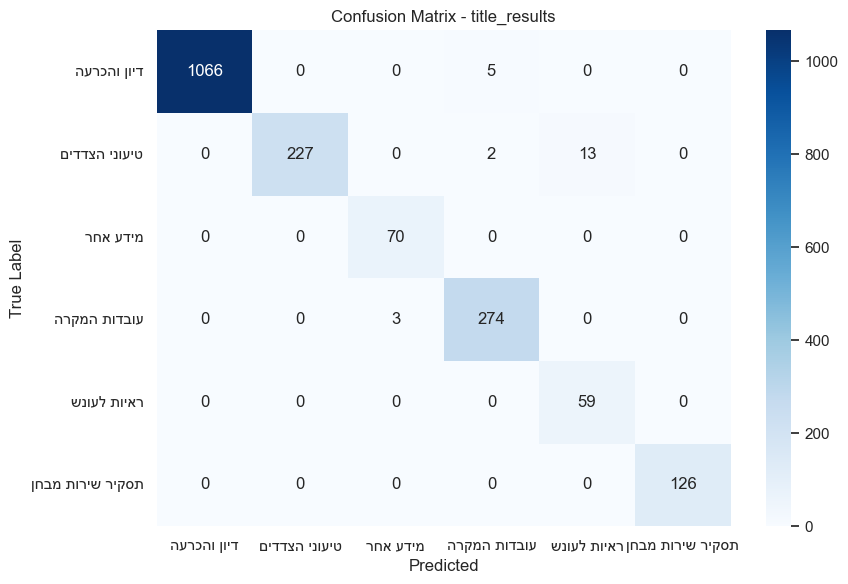


====== Evaluating: text_results ======


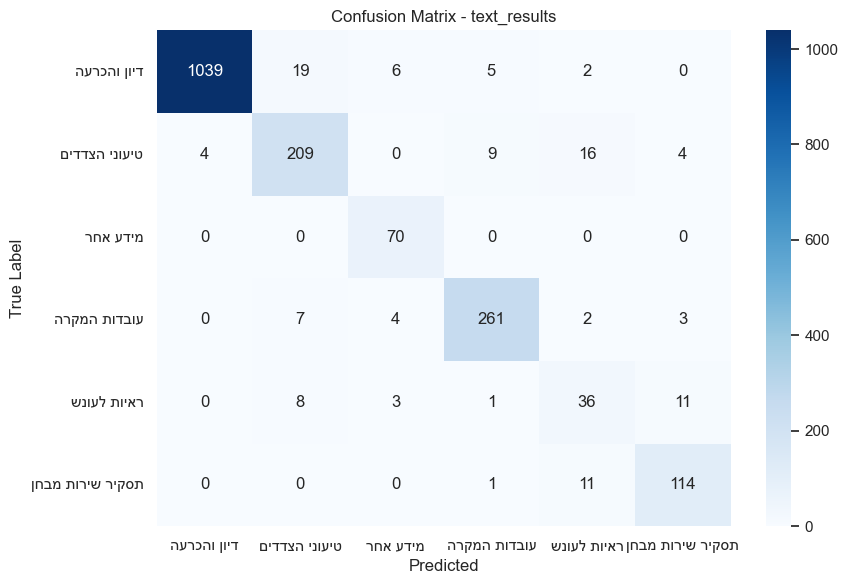


====== Evaluating: text_and_title_results ======


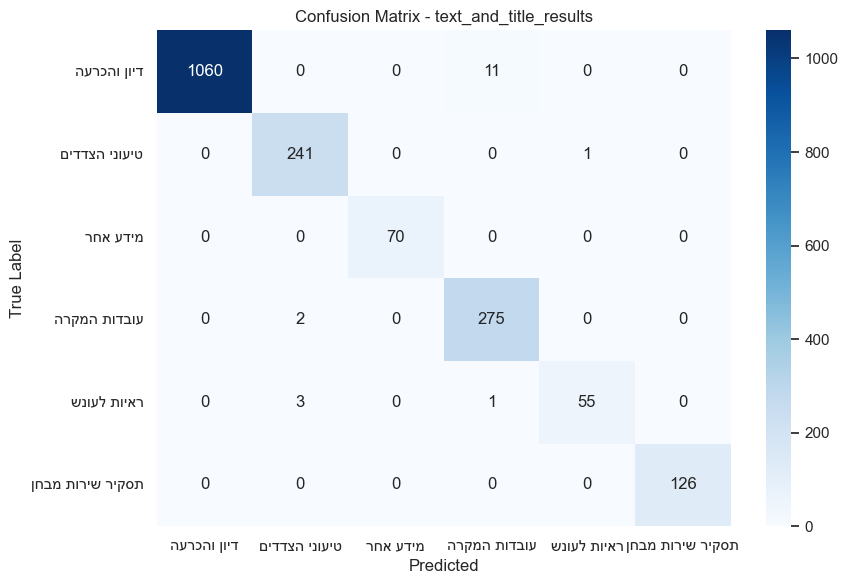


====== Evaluating: whole_case_results ======


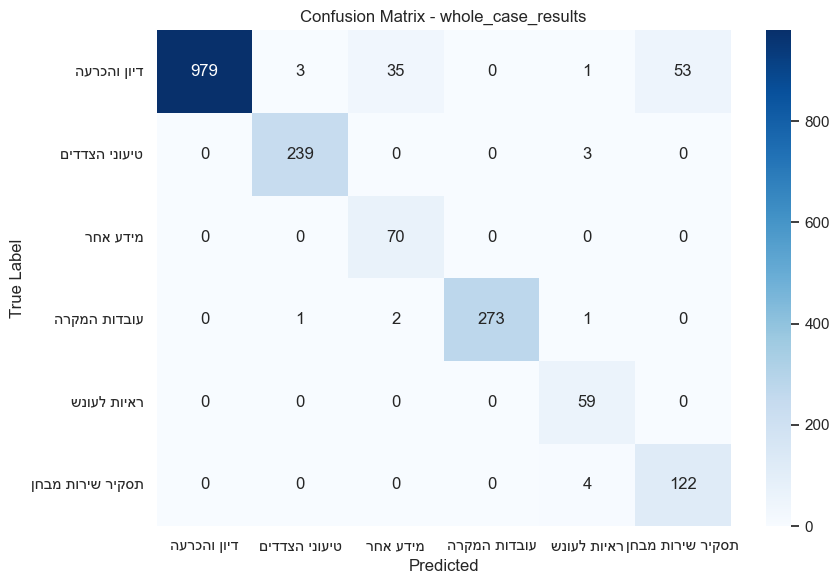


==================== Evaluating TYPE: weapon ====================

====== Evaluating: title_results ======


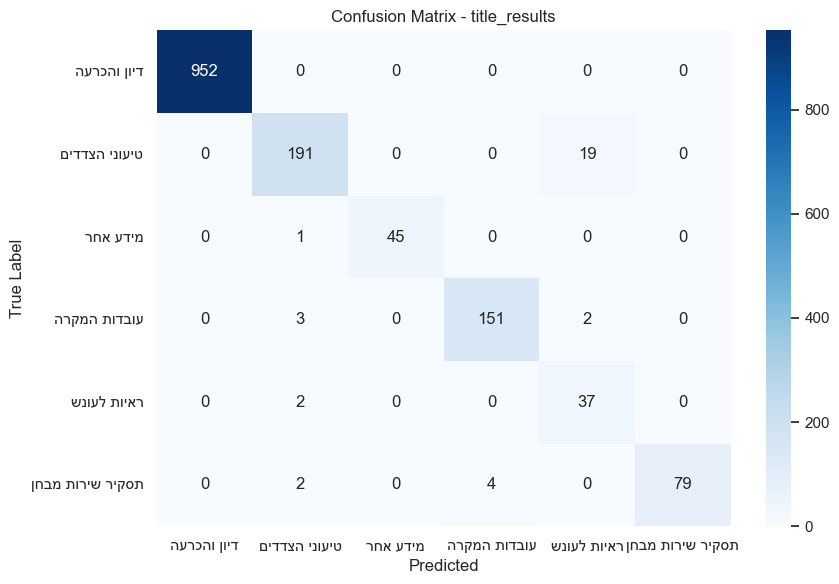


====== Evaluating: text_results ======


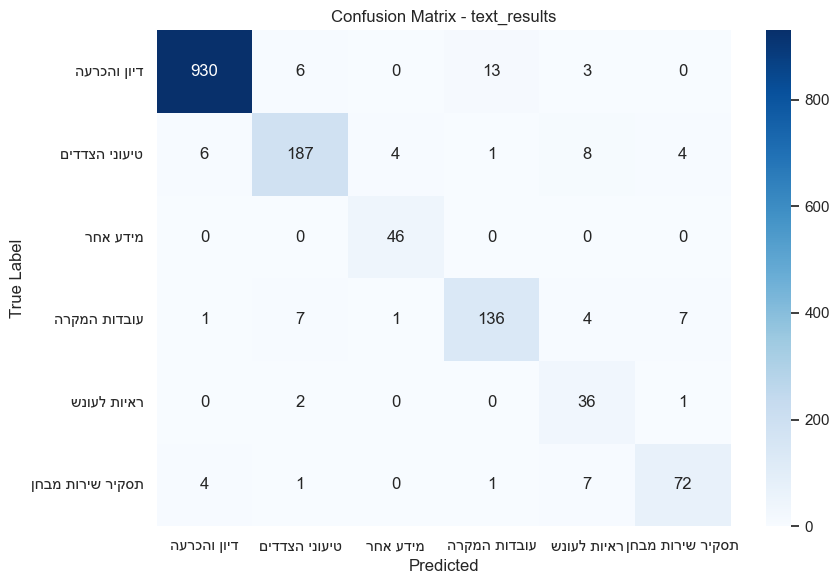


====== Evaluating: text_and_title_results ======


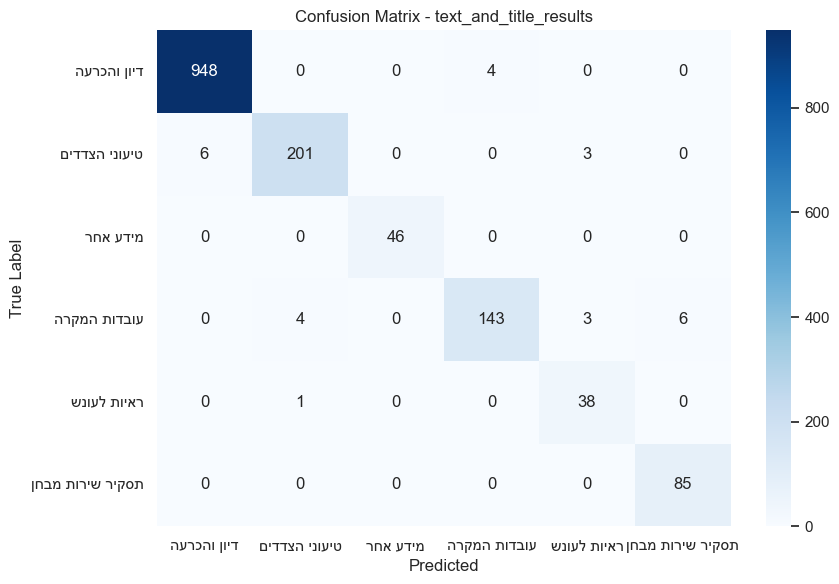


====== Evaluating: whole_case_results ======


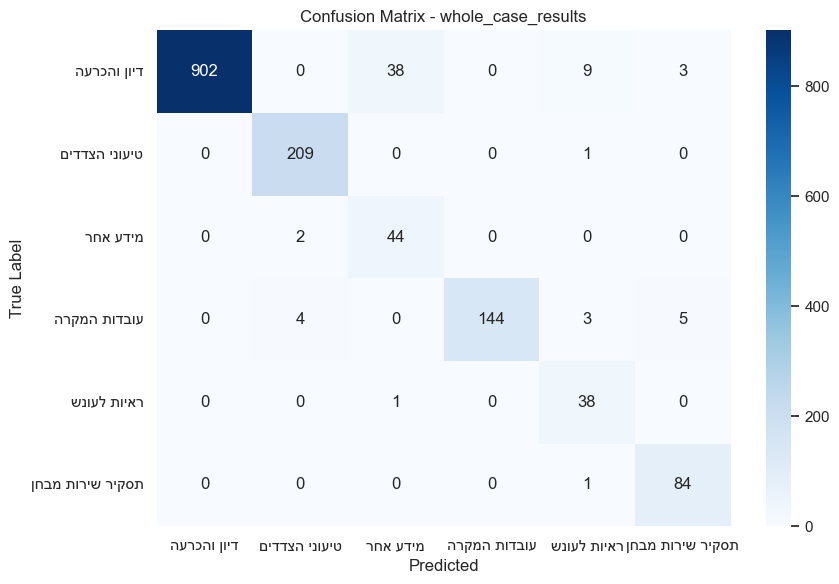

In [27]:
for TYPE in TYPES:
    # -----------------------------
    #  LOAD DATA
    # -----------------------------
    results_df = pd.read_csv(os.path.join(RESULTS_PATH,TYPE, 'all_results.csv'))
    print(f"\n==================== Evaluating TYPE: {TYPE} ====================")
    # Columns to evaluate
    prediction_columns = ['title_results','text_results', 'text_and_title_results', 'whole_case_results']
    ground_truth_column = 'label'

    results_df = results_df.dropna(subset=[ground_truth_column])
    results_df[prediction_columns] = results_df[prediction_columns].fillna('MISSING')

    results_df[ground_truth_column] = results_df[ground_truth_column].astype(str)
    for col in prediction_columns:
        results_df[col] = results_df[col].astype(str)

    unique_labels = sorted(results_df[ground_truth_column].unique())
    unique_labels_display = [get_display(label) for label in unique_labels]

    # Save all per-label rows across all models
    all_per_label_rows = []

    # Global metrics storage
    global_metric_rows = []

    sns.set_theme(style="whitegrid")

    # -----------------------------
    # LOOP OVER MODELS
    # -----------------------------
    for col in prediction_columns:
        print(f"\n====== Evaluating: {col} ======")

        y_true = results_df[ground_truth_column]
        y_pred = results_df[col]

        # Accuracy
        acc = accuracy_score(y_true, y_pred)

        # Micro / Macro / Weighted
        micro_f1 = f1_score(y_true, y_pred, average='micro', zero_division=0)
        macro_f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
        weighted_f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)

        # Save global metrics
        global_metric_rows.append({
            'Input_Type': col,
            'Overall_Accuracy': acc,
            'Micro-F1': micro_f1,
            'Macro-F1': macro_f1,
            'Weighted-F1': weighted_f1
        })

        # -----------------------------
        #  PER-LABEL METRICS
        # -----------------------------
        per_label = []

        for label in unique_labels:
            label_precision = precision_score(y_true, y_pred, labels=[label], average='micro', zero_division=0)
            label_recall = recall_score(y_true, y_pred, labels=[label], average='micro', zero_division=0)
            label_f1 = f1_score(y_true, y_pred, labels=[label], average='micro', zero_division=0)
            support = (y_true == label).sum()

            per_label.append({
                'Input_Type': col,
                'Class': label,
                'Class_Display': get_display(label),
                'Precision': label_precision,
                'Recall': label_recall,
                'F1-Score': label_f1,
                'Support': support
            })

        # Convert to DataFrame
        per_label_df = pd.DataFrame(per_label)

        # Add to global per-class storage
        all_per_label_rows.append(per_label_df)

        
        # -----------------------------
        # VISUALIZATIONS
        # -----------------------------

        # 1. Confusion Matrix
        cm = confusion_matrix(y_true, y_pred, labels=unique_labels)
        plt.figure(figsize=(9, 6))
        sns.heatmap(cm, annot=True, fmt='d', cmap="Blues",
                    xticklabels=unique_labels_display, yticklabels=unique_labels_display)
        plt.title(f"Confusion Matrix - {col}")
        plt.xlabel("Predicted")
        plt.ylabel("True Label")
        plt.tight_layout()
        plt.show()




## Count of Each Label

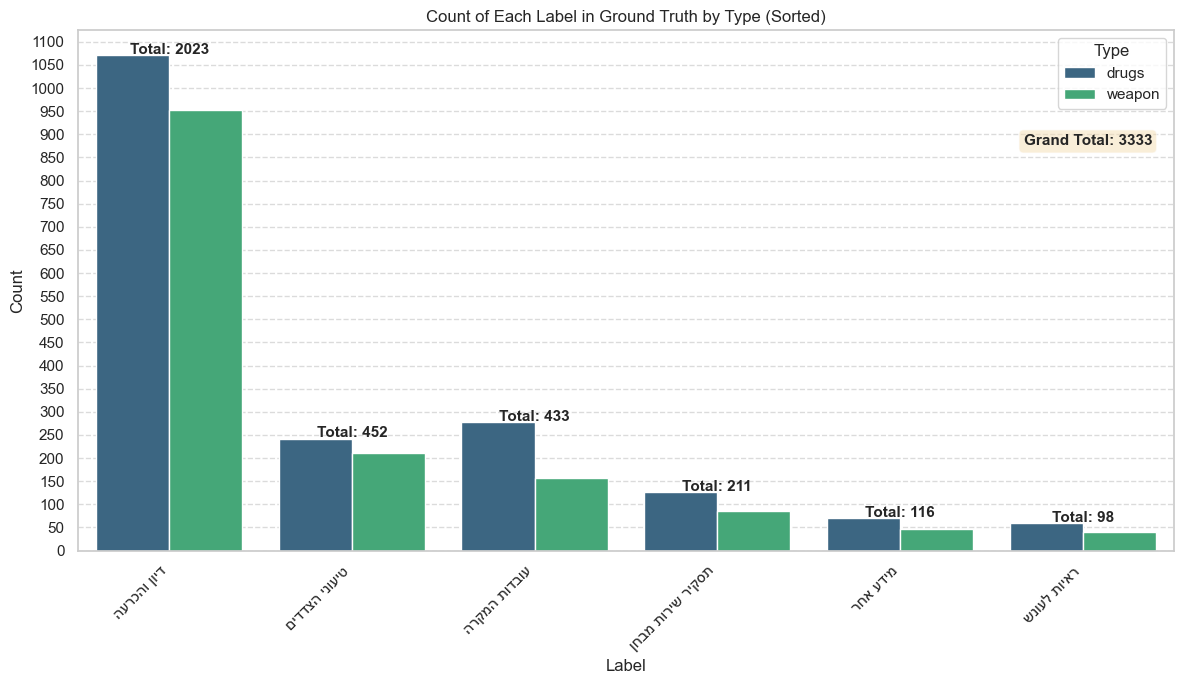

In [28]:
gt_dfs = []
for TYPE in TYPES:
    gt_df = pd.read_csv(os.path.join(RESULTS_PATH,TYPE, 'all_results.csv'))
    gt_df['type'] = TYPE
    gt_dfs.append(gt_df)
combined_gt_df = pd.concat(gt_dfs, ignore_index=True)

# Calculate counts and sort by total (descending - largest on left)
label_counts = combined_gt_df.groupby('label').size().reset_index(name='total')
label_order = label_counts.sort_values('total', ascending=False)['label'].tolist()

# Create display labels (RTL fix)
combined_gt_df['label_display'] = combined_gt_df['label'].apply(get_display)
label_order_display = [get_display(l) for l in label_order]

# Calculate totals for annotation
totals_per_label = combined_gt_df.groupby('label_display').size().to_dict()

plt.figure(figsize=(12, 7))
ax = sns.countplot(data=combined_gt_df, x='label_display', hue='type', 
                   order=label_order_display, palette='viridis')

# Add horizontal grid lines at y=50 intervals
ax.yaxis.set_major_locator(plt.MultipleLocator(50))
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Add total annotations on top of bars
for label_display in label_order_display:
    total = totals_per_label.get(label_display, 0)
    x_pos = label_order_display.index(label_display)
    # Get the max height for this label
    max_height = 0
    for p in ax.patches:
        if abs(p.get_x() + p.get_width()/2 - x_pos) < 0.5:
            max_height = max(max_height, p.get_height())
    ax.annotate(f'Total: {total}', (x_pos, max_height + 3), ha='center', fontsize=11, fontweight='bold')

plt.title('Count of Each Label in Ground Truth by Type (Sorted)')
plt.xlabel('Label')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')

# Add legend with grand total next to it
grand_total = len(combined_gt_df)
legend = plt.legend(title='Type', loc='upper right')
ax.annotate(f'Grand Total: {grand_total}', xy=(0.98, 0.8), xycoords='axes fraction',
             ha='right', va='top', fontsize=11, fontweight='bold',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

## Per Label Calculation

DRUGS


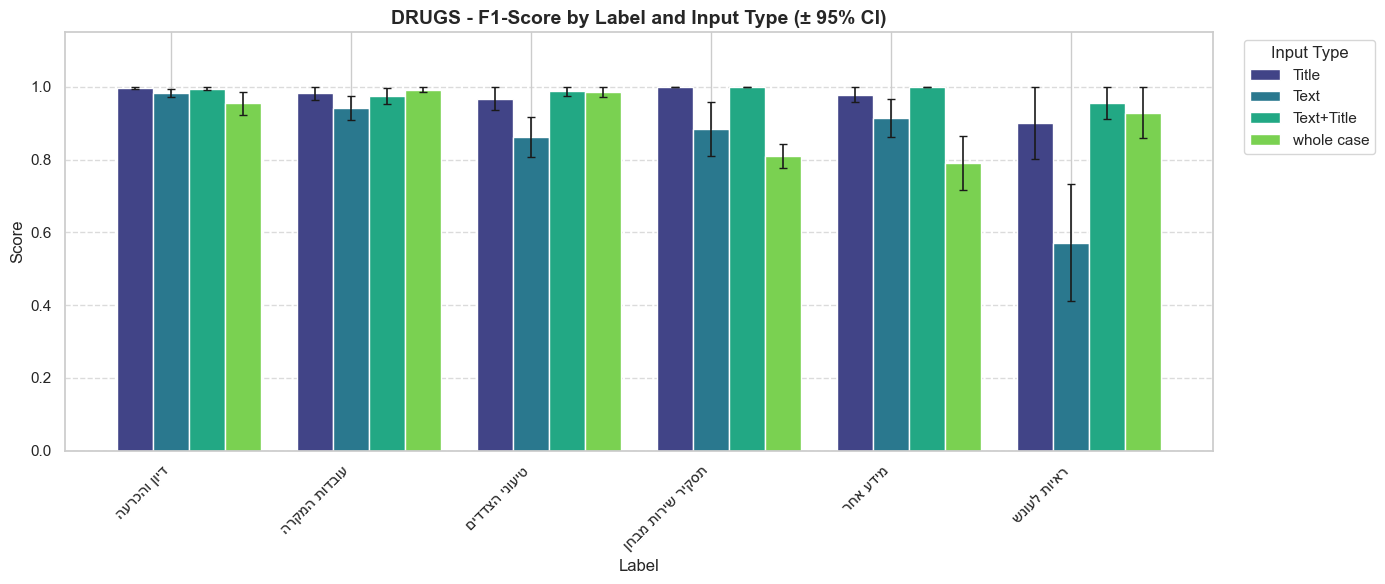

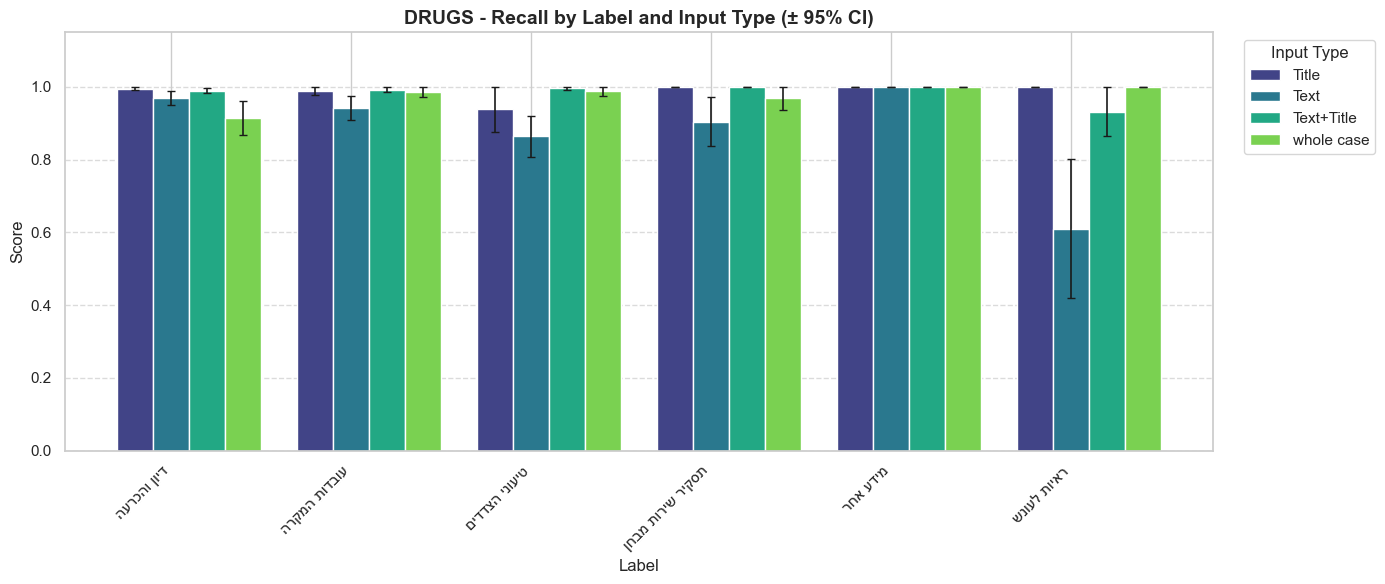

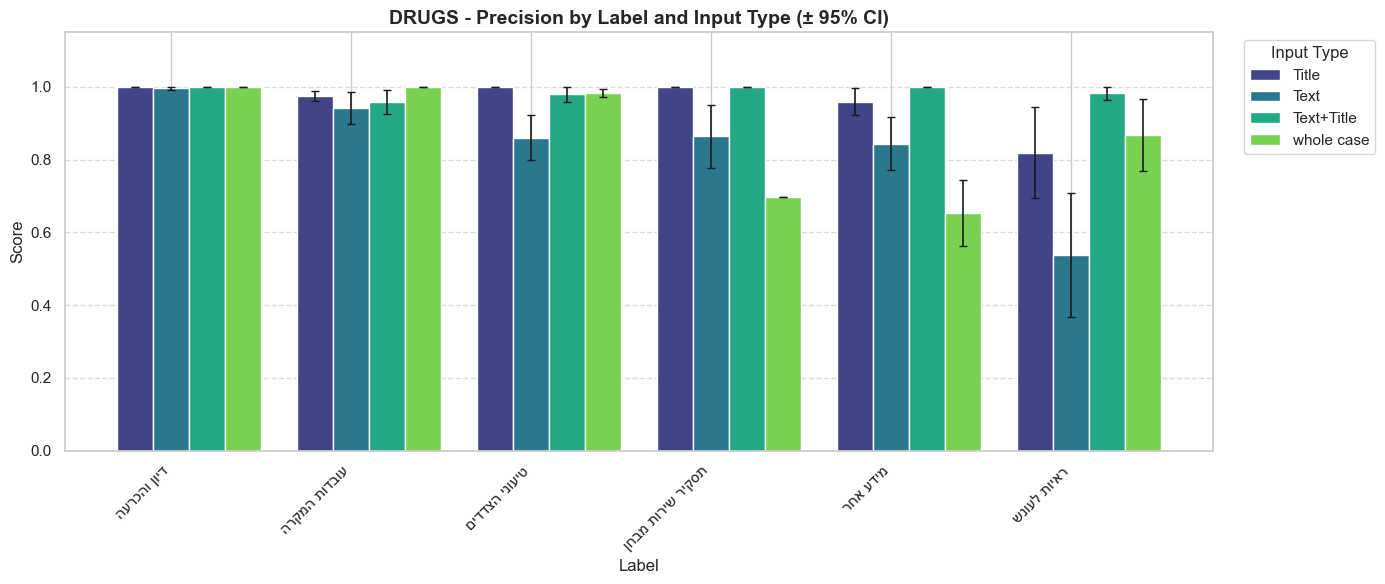

WEAPON


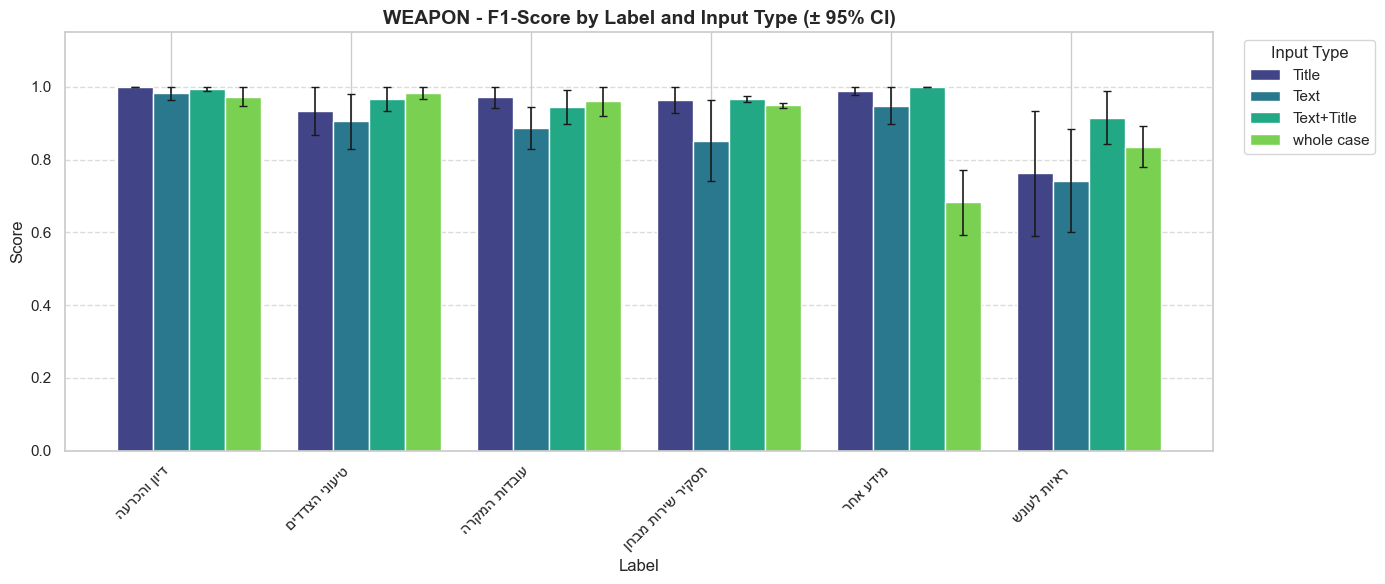

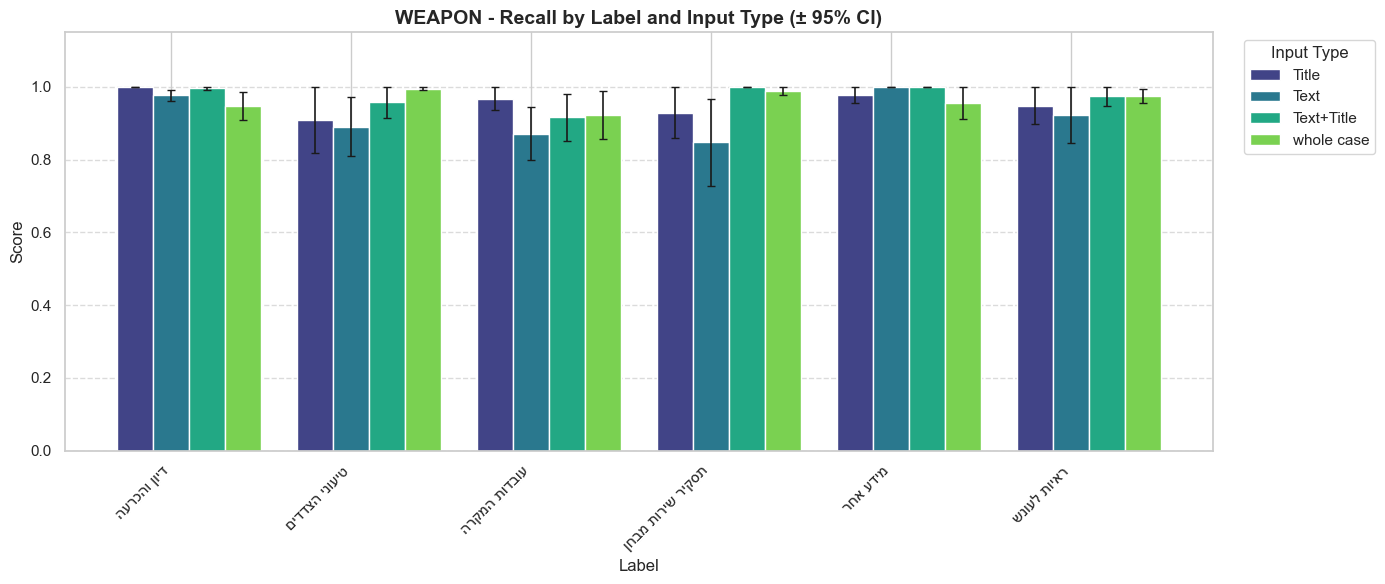

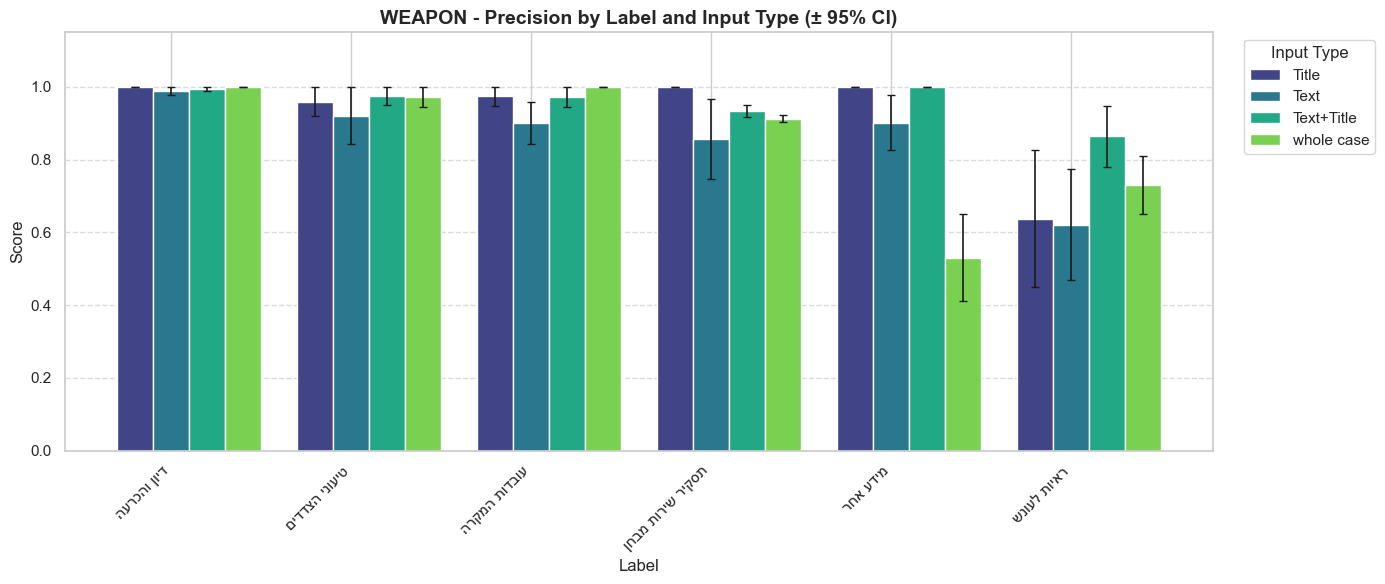

COMBINED (Drugs + Weapon)
       Label_Display  Input_Type  Precision_mean  Precision_std  Precision_n  \
0        הערכהו ןויד        Text        0.992238       0.005554            2   
1        הערכהו ןויד  Text+Title        0.996855       0.004447            2   
2        הערכהו ןויד       Title        1.000000       0.000000            2   
3        הערכהו ןויד  whole case        1.000000       0.000000            2   
4       הרקמה תודבוע        Text        0.921450       0.029399            2   
5       הרקמה תודבוע  Text+Title        0.965489       0.010324            2   
6       הרקמה תודבוע       Title        0.974641       0.000633            2   
7       הרקמה תודבוע  whole case        1.000000       0.000000            2   
8      םידדצה ינועיט        Text        0.890632       0.043204            2   
9      םידדצה ינועיט  Text+Title        0.977701       0.002791            2   
10     םידדצה ינועיט       Title        0.979899       0.028426            2   
11     םידדצה 

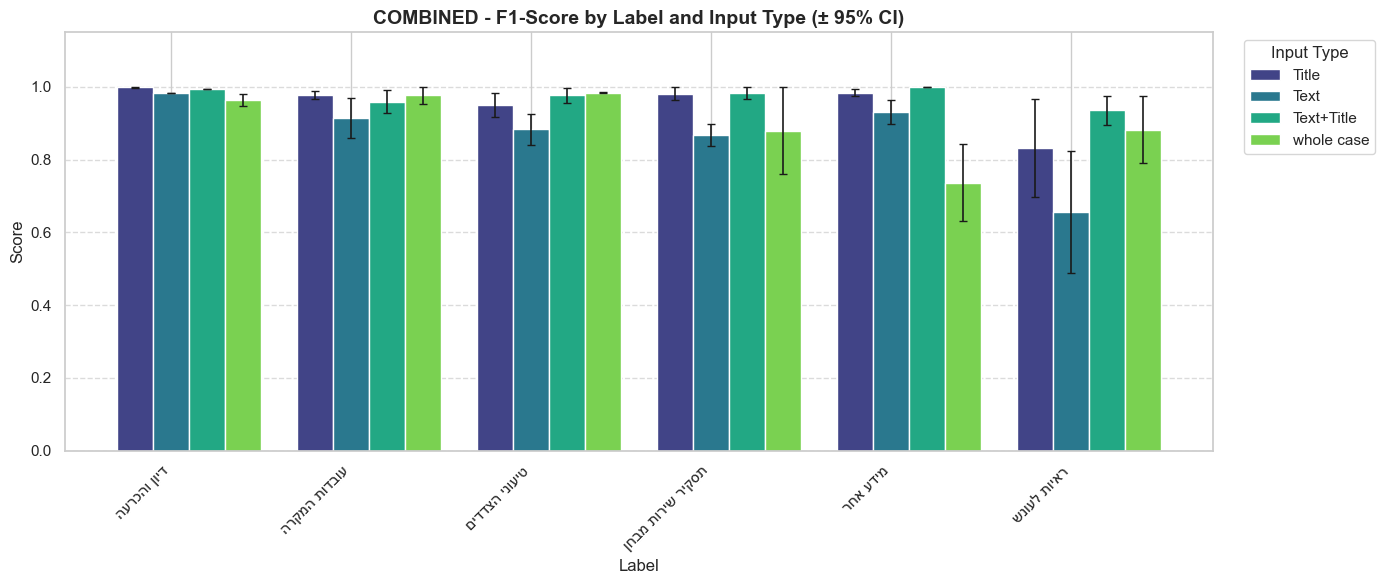

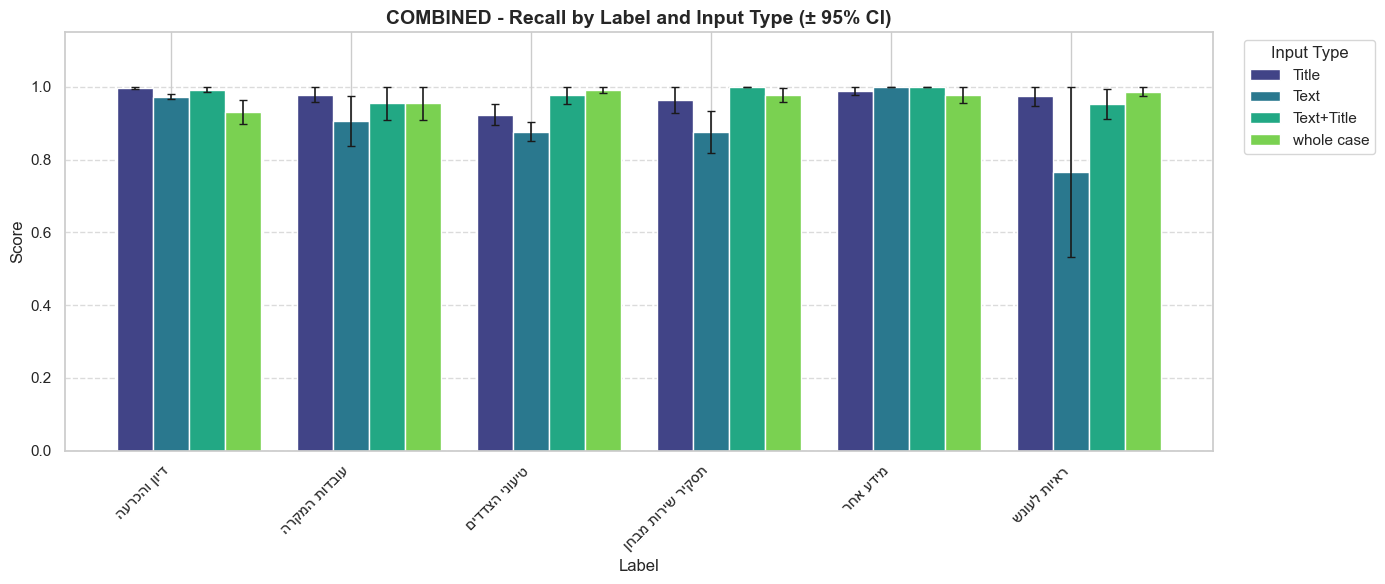

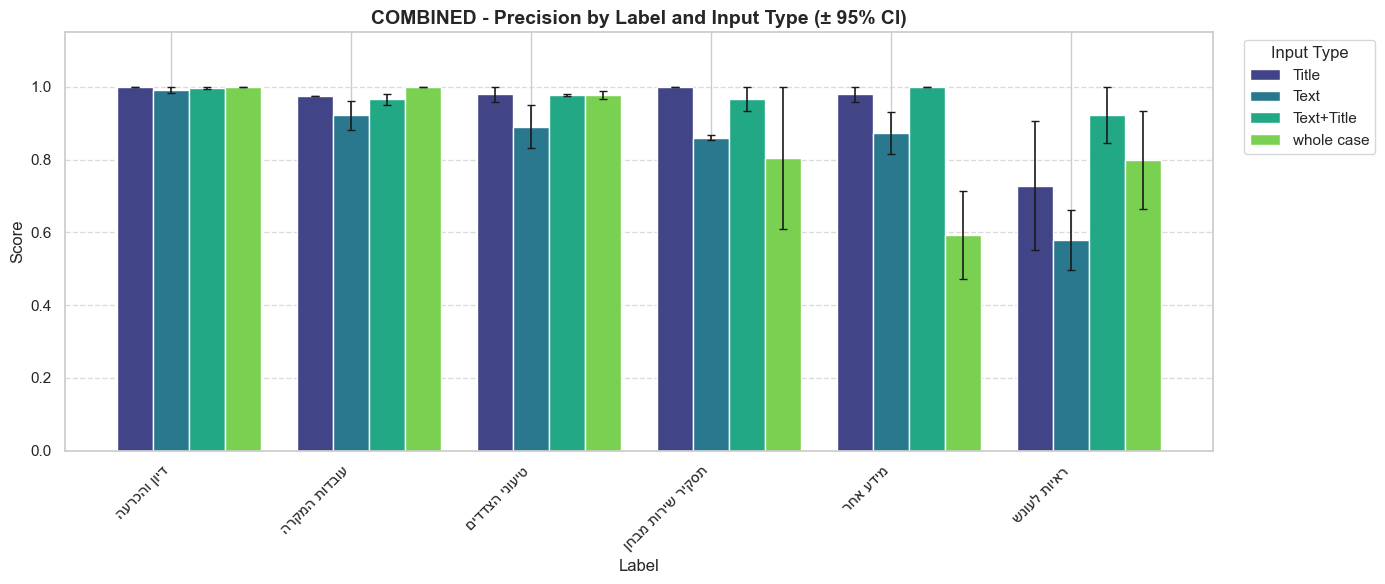

In [43]:
all_metrics = []
all_file_metrics = []  # Per-file metrics for error bars

# Z-score for 95% CI
Z_95 = 1.96

def clip_ci(mean_val, ci_val):
    """Clip CI so that mean + ci <= 1 and mean - ci >= 0"""
    upper_limit = 1.0 - mean_val
    lower_limit = mean_val
    return min(ci_val, upper_limit, lower_limit)

for TYPE in TYPES:
    results_df = pd.read_csv(os.path.join(RESULTS_PATH,TYPE, 'all_results.csv'))
    prediction_columns = ['title_results', 'text_results', 'text_and_title_results', 'whole_case_results']
    ground_truth_column = 'label'
    
    results_df = results_df.dropna(subset=[ground_truth_column])
    results_df[prediction_columns] = results_df[prediction_columns].fillna('MISSING')
    results_df[ground_truth_column] = results_df[ground_truth_column].astype(str)
    for col in prediction_columns:
        results_df[col] = results_df[col].astype(str)
    
    unique_labels = sorted(results_df[ground_truth_column].unique())
    
    # Get file list for per-file metrics
    path = os.path.join(RESULTS_PATH, TYPE, "only_title")
    files = [f for f in os.listdir(path) if f.endswith('.csv')]
    
    for col in prediction_columns:
        y_true = results_df[ground_truth_column]
        y_pred = results_df[col]
        
        # Overall metrics per label
        for label in unique_labels:
            label_precision = precision_score(y_true, y_pred, labels=[label], average='micro', zero_division=0)
            label_recall = recall_score(y_true, y_pred, labels=[label], average='micro', zero_division=0)
            label_f1 = f1_score(y_true, y_pred, labels=[label], average='micro', zero_division=0)
            
            input_name = {'title_results': 'Title', 'text_results': 'Text', 'text_and_title_results': 'Text+Title', 'whole_case_results': 'whole case'}[col]
            
            all_metrics.append({
                'Type': TYPE,
                'Label': label,
                'Label_Display': get_display(label),
                'Input_Type': input_name,
                'Precision': label_precision,
                'Recall': label_recall,
                'F1-Score': label_f1
            })
        
        # Per-file metrics for error bars
        case_map = {'title_results': 'only_title', 'text_results': 'only_text', 'text_and_title_results': 'text_and_title', 'whole_case_results': 'whole_case'}
        case = case_map[col]
        input_name = {'title_results': 'Title', 'text_results': 'Text', 'text_and_title_results': 'Text+Title', 'whole_case_results': 'whole case'}[col]
        start_idx = 0
        
        for file in files:
            file_path = os.path.join(RESULTS_PATH, TYPE, case, file)
            if os.path.exists(file_path):
                file_df = pd.read_csv(file_path)
                file_len = len(file_df)
                if file_len > 0:
                    file_y_true = y_true.iloc[start_idx:start_idx + file_len]
                    file_y_pred = y_pred.iloc[start_idx:start_idx + file_len]
                    
                    for label in unique_labels:
                        if (file_y_true == label).sum() > 0:  # Only if label exists in file
                            file_precision = precision_score(file_y_true, file_y_pred, labels=[label], average='micro', zero_division=0)
                            file_recall = recall_score(file_y_true, file_y_pred, labels=[label], average='micro', zero_division=0)
                            file_f1 = f1_score(file_y_true, file_y_pred, labels=[label], average='micro', zero_division=0)
                            
                            all_file_metrics.append({
                                'Type': TYPE,
                                'File': file,
                                'Label': label,
                                'Label_Display': get_display(label),
                                'Input_Type': input_name,
                                'Precision': file_precision,
                                'Recall': file_recall,
                                'F1-Score': file_f1
                            })
                    
                start_idx += file_len

metrics_df = pd.DataFrame(all_metrics)
file_metrics_df = pd.DataFrame(all_file_metrics)

metrics_to_plot = [('F1-Score', 'F1-Score'), ('Recall', 'Recall'), ('Precision', 'Precision')]

# =====================
# DRUGS - 3 plots with 95% CI error bars
# =====================
print("=" * 50)
print("DRUGS")
print("=" * 50)

drugs_df = metrics_df[metrics_df['Type'] == 'drugs']
drugs_file_df = file_metrics_df[file_metrics_df['Type'] == 'drugs']

# Calculate 95% CI from per-file metrics: CI = Z * (std / sqrt(n))
drugs_ci_df = drugs_file_df.groupby(['Label_Display', 'Input_Type']).agg({
    'Precision': ['std', 'count'],
    'Recall': ['std', 'count'],
    'F1-Score': ['std', 'count']
}).reset_index()
drugs_ci_df.columns = ['Label_Display', 'Input_Type', 
                       'Precision_std', 'Precision_n', 
                       'Recall_std', 'Recall_n', 
                       'F1-Score_std', 'F1-Score_n']
drugs_ci_df = drugs_ci_df.fillna(0)
# Calculate 95% CI
drugs_ci_df['Precision_ci'] = Z_95 * drugs_ci_df['Precision_std'] / np.sqrt(drugs_ci_df['Precision_n'].replace(0, 1))
drugs_ci_df['Recall_ci'] = Z_95 * drugs_ci_df['Recall_std'] / np.sqrt(drugs_ci_df['Recall_n'].replace(0, 1))
drugs_ci_df['F1-Score_ci'] = Z_95 * drugs_ci_df['F1-Score_std'] / np.sqrt(drugs_ci_df['F1-Score_n'].replace(0, 1))

drugs_label_order = drugs_df.groupby('Label_Display')['F1-Score'].mean().sort_values(ascending=False).index.tolist()

for metric_col, metric_name in metrics_to_plot:
    plt.figure(figsize=(14, 6))
    
    input_order = ['Title', 'Text', 'Text+Title', 'whole case']
    x = np.arange(len(drugs_label_order))
    width = 0.2
    colors = sns.color_palette('viridis', 4)
    
    for i, input_type in enumerate(input_order):
        means = []
        cis = []
        for label in drugs_label_order:
            row = drugs_df[(drugs_df['Label_Display'] == label) & (drugs_df['Input_Type'] == input_type)]
            ci_row = drugs_ci_df[(drugs_ci_df['Label_Display'] == label) & (drugs_ci_df['Input_Type'] == input_type)]
            mean_val = row[metric_col].values[0] if len(row) > 0 else 0
            ci_val = ci_row[f'{metric_col}_ci'].values[0] if len(ci_row) > 0 else 0
            means.append(mean_val)
            # Clip CI so error bars don't exceed [0, 1]
            cis.append(clip_ci(mean_val, ci_val))
        
        bars = plt.bar(x + i * width, means, width, label=input_type, color=colors[i],
                       yerr=cis, capsize=3, error_kw={'linewidth': 1.2})
    
    plt.xlabel('Label', fontsize=12)
    plt.ylabel('Score', fontsize=12)
    plt.title(f'DRUGS - {metric_name} by Label and Input Type (± 95% CI)', fontsize=14, fontweight='bold')
    plt.xticks(x + width, drugs_label_order, rotation=45, ha='right')
    plt.ylim(0, 1.15)
    plt.legend(title='Input Type', bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

# =====================
# WEAPON - 3 plots with 95% CI error bars
# =====================
print("=" * 50)
print("WEAPON")
print("=" * 50)

weapon_df = metrics_df[metrics_df['Type'] == 'weapon']
weapon_file_df = file_metrics_df[file_metrics_df['Type'] == 'weapon']

# Calculate 95% CI from per-file metrics
weapon_ci_df = weapon_file_df.groupby(['Label_Display', 'Input_Type']).agg({
    'Precision': ['std', 'count'],
    'Recall': ['std', 'count'],
    'F1-Score': ['std', 'count']
}).reset_index()
weapon_ci_df.columns = ['Label_Display', 'Input_Type', 
                        'Precision_std', 'Precision_n', 
                        'Recall_std', 'Recall_n', 
                        'F1-Score_std', 'F1-Score_n']
weapon_ci_df = weapon_ci_df.fillna(0)
# Calculate 95% CI
weapon_ci_df['Precision_ci'] = Z_95 * weapon_ci_df['Precision_std'] / np.sqrt(weapon_ci_df['Precision_n'].replace(0, 1))
weapon_ci_df['Recall_ci'] = Z_95 * weapon_ci_df['Recall_std'] / np.sqrt(weapon_ci_df['Recall_n'].replace(0, 1))
weapon_ci_df['F1-Score_ci'] = Z_95 * weapon_ci_df['F1-Score_std'] / np.sqrt(weapon_ci_df['F1-Score_n'].replace(0, 1))

weapon_label_order = weapon_df.groupby('Label_Display')['F1-Score'].mean().sort_values(ascending=False).index.tolist()

for metric_col, metric_name in metrics_to_plot:
    plt.figure(figsize=(14, 6))
    
    input_order = ['Title', 'Text', 'Text+Title', 'whole case']
    x = np.arange(len(weapon_label_order))
    width = 0.2
    colors = sns.color_palette('viridis', 4)
    
    for i, input_type in enumerate(input_order):
        means = []
        cis = []
        for label in weapon_label_order:
            row = weapon_df[(weapon_df['Label_Display'] == label) & (weapon_df['Input_Type'] == input_type)]
            ci_row = weapon_ci_df[(weapon_ci_df['Label_Display'] == label) & (weapon_ci_df['Input_Type'] == input_type)]
            mean_val = row[metric_col].values[0] if len(row) > 0 else 0
            ci_val = ci_row[f'{metric_col}_ci'].values[0] if len(ci_row) > 0 else 0
            means.append(mean_val)
            # Clip CI so error bars don't exceed [0, 1]
            cis.append(clip_ci(mean_val, ci_val))
        
        bars = plt.bar(x + i * width, means, width, label=input_type, color=colors[i],
                       yerr=cis, capsize=3, error_kw={'linewidth': 1.2})
    
    plt.xlabel('Label', fontsize=12)
    plt.ylabel('Score', fontsize=12)
    plt.title(f'WEAPON - {metric_name} by Label and Input Type (± 95% CI)', fontsize=14, fontweight='bold')
    plt.xticks(x + width, weapon_label_order, rotation=45, ha='right')
    plt.ylim(0, 1.15)
    plt.legend(title='Input Type', bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

# =====================
# COMBINED (Drugs + Weapon) - 3 plots with 95% CI error bars
# =====================
print("=" * 50)
print("COMBINED (Drugs + Weapon)")
print("=" * 50)

# Aggregate by Label and Input Type (mean and 95% CI across drugs and weapon)
combined_agg = metrics_df.groupby(['Label_Display', 'Input_Type']).agg({
    'Precision': ['mean', 'std', 'count'],
    'Recall': ['mean', 'std', 'count'],
    'F1-Score': ['mean', 'std', 'count']
}).reset_index()
combined_agg.columns = ['Label_Display', 'Input_Type', 
                        'Precision_mean', 'Precision_std', 'Precision_n',
                        'Recall_mean', 'Recall_std', 'Recall_n',
                        'F1-Score_mean', 'F1-Score_std', 'F1-Score_n']
combined_agg = combined_agg.fillna(0)
# Calculate 95% CI
combined_agg['Precision_ci'] = Z_95 * combined_agg['Precision_std'] / np.sqrt(combined_agg['Precision_n'].replace(0, 1))
combined_agg['Recall_ci'] = Z_95 * combined_agg['Recall_std'] / np.sqrt(combined_agg['Recall_n'].replace(0, 1))
combined_agg['F1-Score_ci'] = Z_95 * combined_agg['F1-Score_std'] / np.sqrt(combined_agg['F1-Score_n'].replace(0, 1))
print(combined_agg)
combined_label_order = combined_agg.groupby('Label_Display')['F1-Score_mean'].mean().sort_values(ascending=False).index.tolist()

for metric_col, metric_name in metrics_to_plot:
    plt.figure(figsize=(14, 6))
    
    input_order = ['Title', 'Text', 'Text+Title', 'whole case']
    x = np.arange(len(combined_label_order))
    width = 0.2
    colors = sns.color_palette('viridis', 4)
    
    for i, input_type in enumerate(input_order):
        means = []
        cis = []
        for label in combined_label_order:
            row = combined_agg[(combined_agg['Label_Display'] == label) & (combined_agg['Input_Type'] == input_type)]
            mean_val = row[f'{metric_col}_mean'].values[0] if len(row) > 0 else 0
            ci_val = row[f'{metric_col}_ci'].values[0] if len(row) > 0 else 0
            means.append(mean_val)
            # Clip CI so error bars don't exceed [0, 1]
            cis.append(clip_ci(mean_val, ci_val))
        
        bars = plt.bar(x + i * width, means, width, label=input_type, color=colors[i],
                       yerr=cis, capsize=3, error_kw={'linewidth': 1.2})
    
    plt.xlabel('Label', fontsize=12)
    plt.ylabel('Score', fontsize=12)
    plt.title(f'COMBINED - {metric_name} by Label and Input Type (± 95% CI)', fontsize=14, fontweight='bold')
    plt.xticks(x + width, combined_label_order, rotation=45, ha='right')
    plt.ylim(0, 1.15)
    plt.legend(title='Input Type', bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

DRUGS


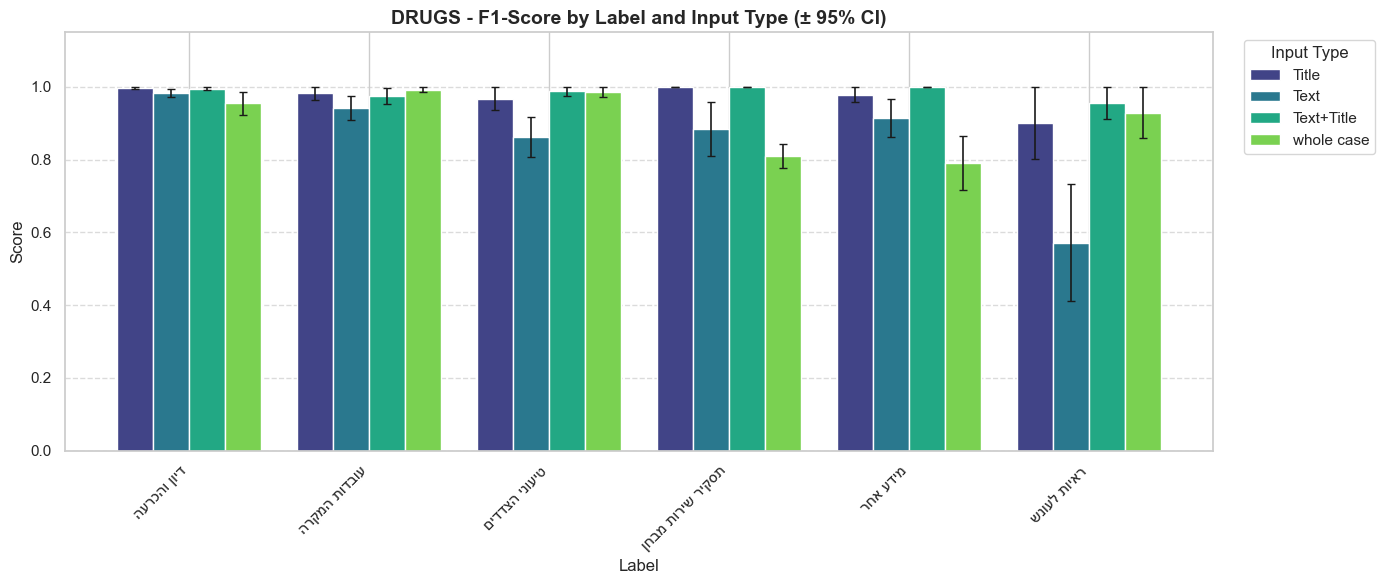

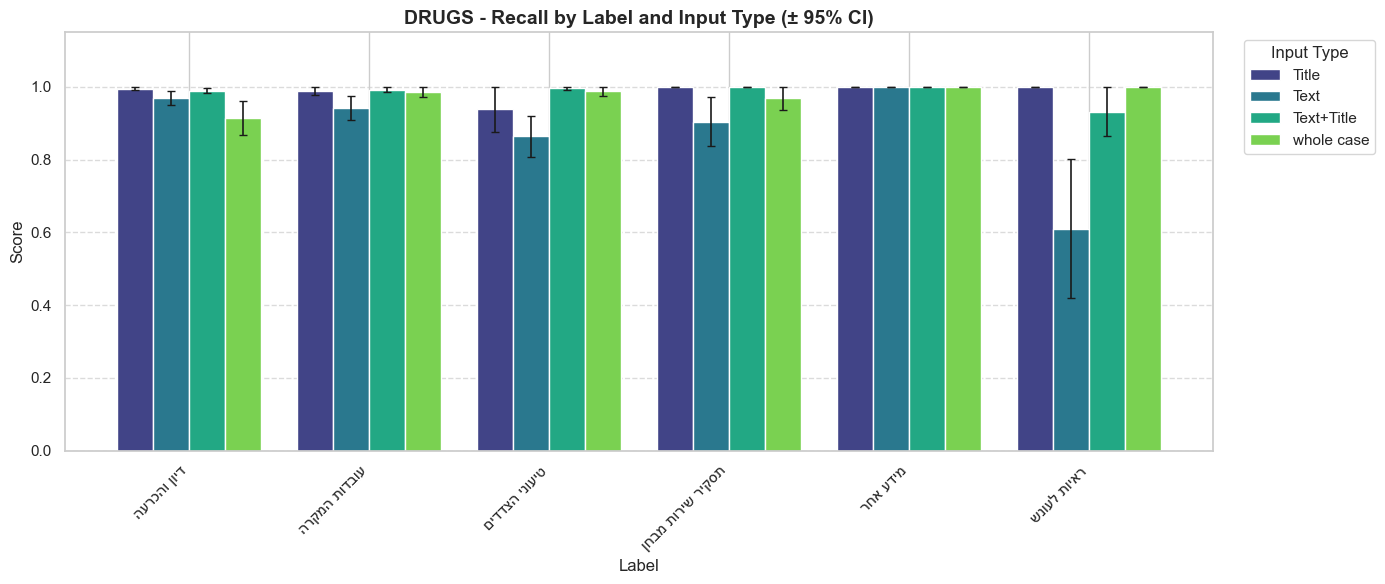

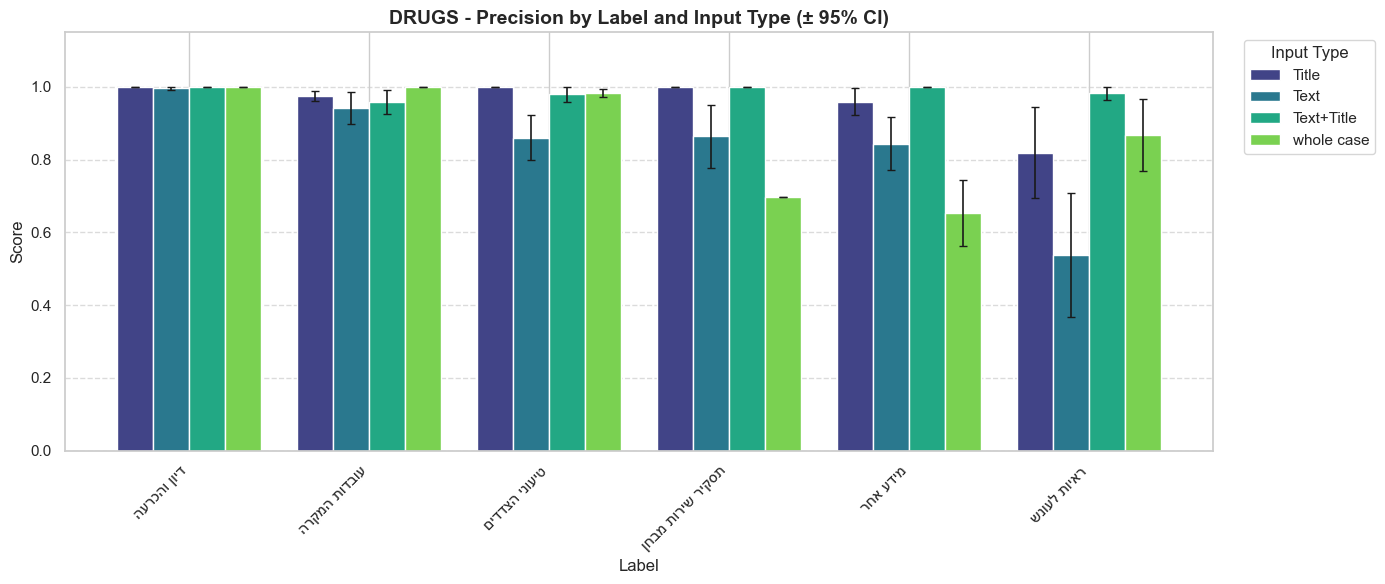

WEAPON


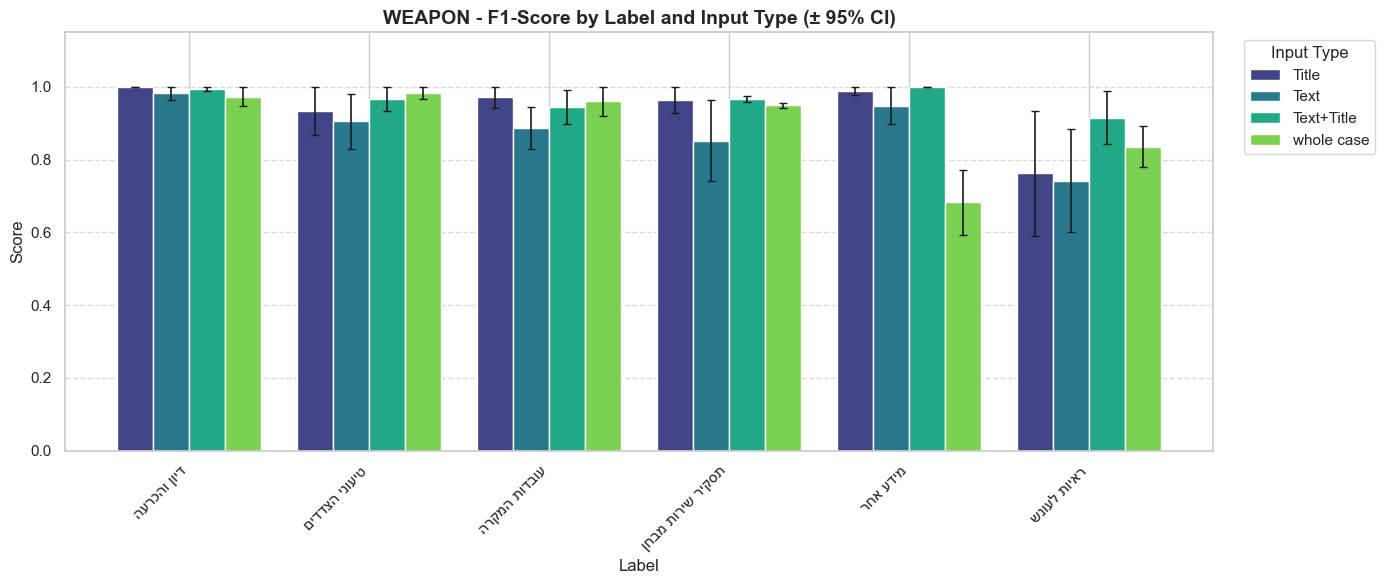

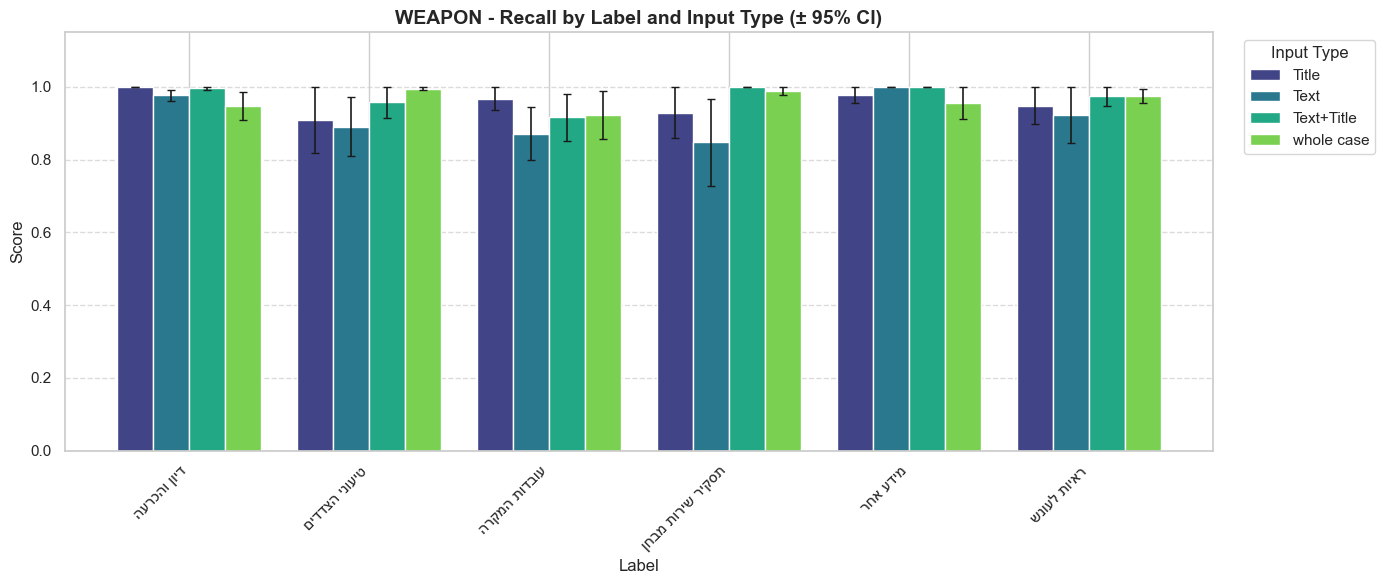

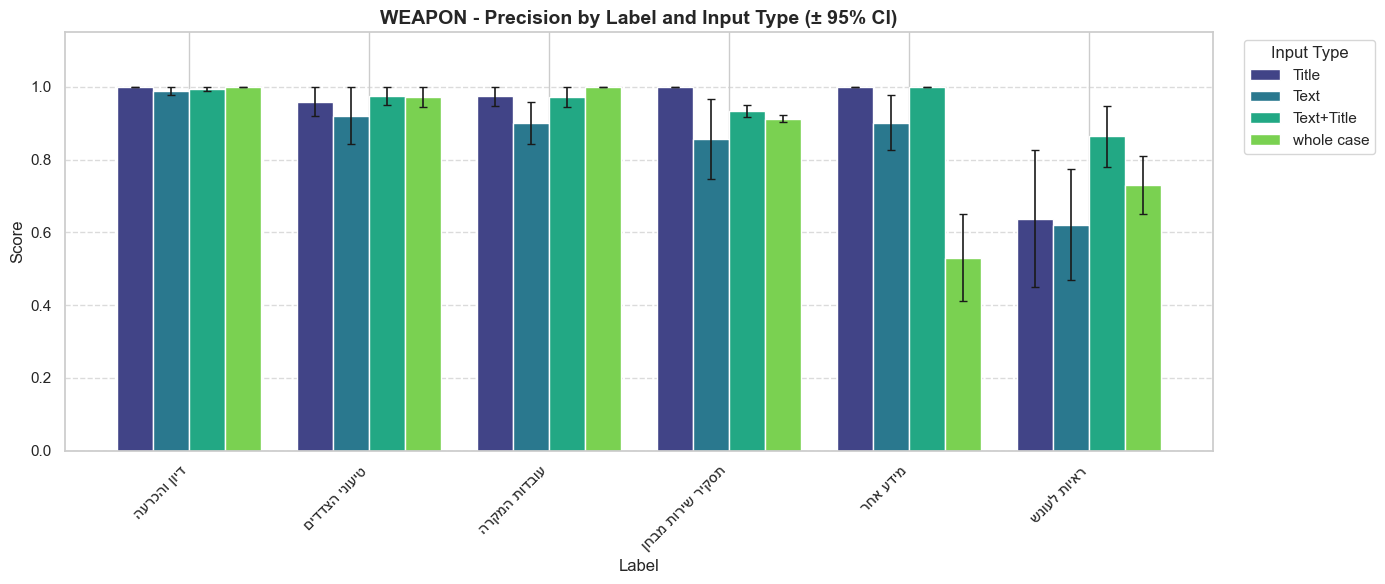

COMBINED (Drugs + Weapon)


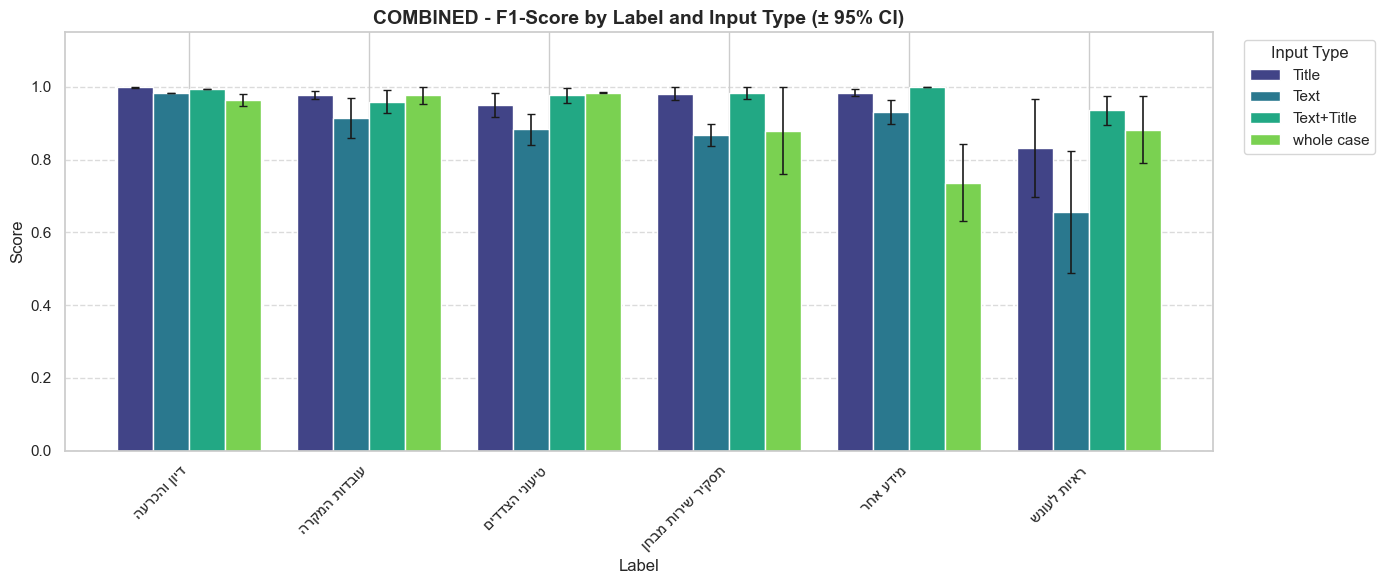

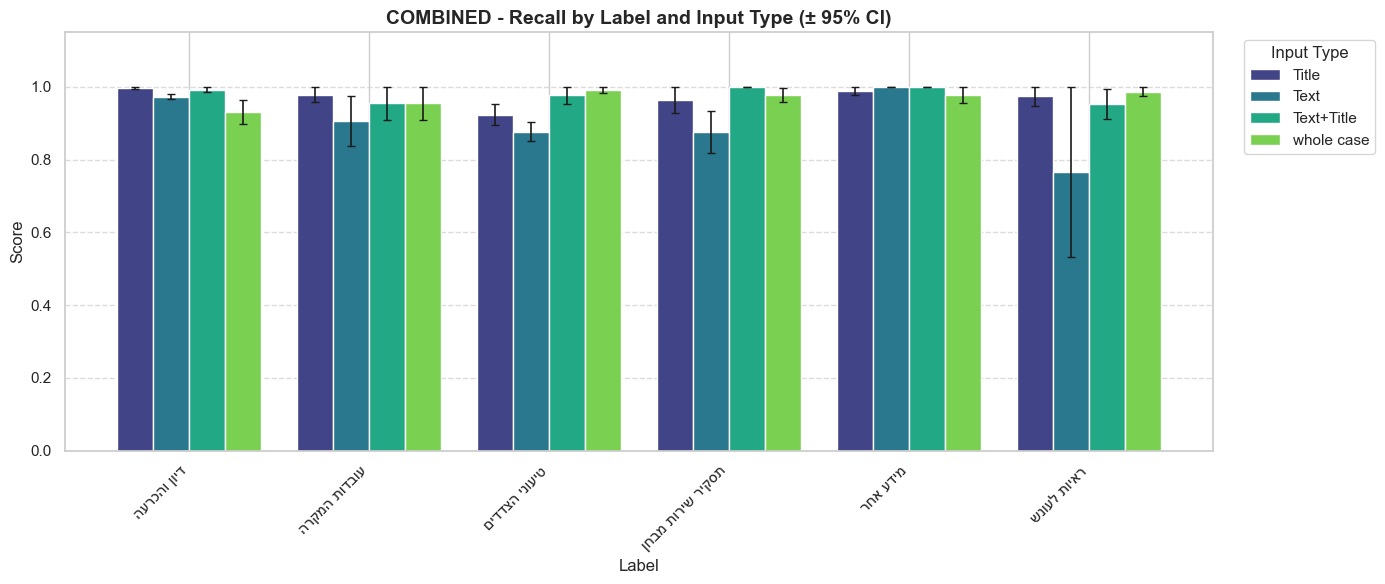

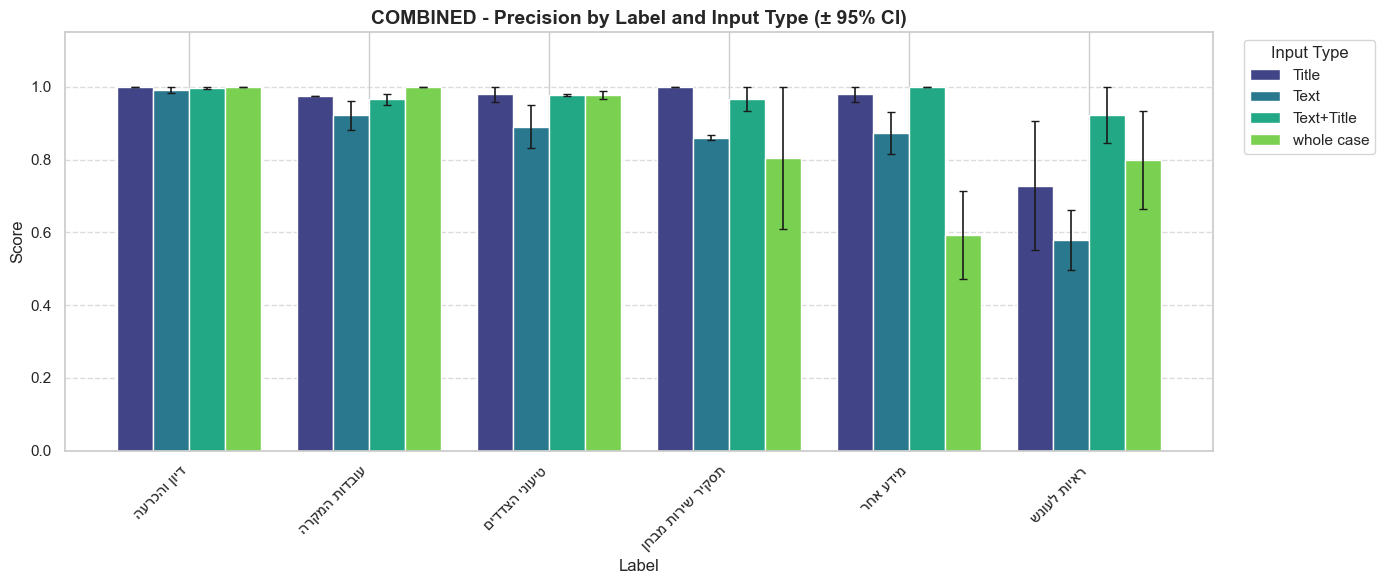

In [ ]:

# =============================================================================
# Constants / קבועים
# =============================================================================

Z_95 = 1.96  # Z-score for 95% confidence interval

PREDICTION_COLUMNS = [
    'title_results',
    'text_results', 
    'text_and_title_results',
    'whole_case_results'
]

GROUND_TRUTH_COL = 'label'

# Mapping from column names to display names
INPUT_NAME_MAP = {
    'title_results': 'Title',
    'text_results': 'Text',
    'text_and_title_results': 'Text+Title',
    'whole_case_results': 'whole case'
}

# Mapping from column names to result directory names
CASE_DIR_MAP = {
    'title_results': 'only_title',
    'text_results': 'only_text',
    'text_and_title_results': 'text_and_title',
    'whole_case_results': 'whole_case'
}

METRICS = ['Precision', 'Recall', 'F1-Score']
INPUT_ORDER = ['Title', 'Text', 'Text+Title', 'whole case']


# =============================================================================
# Helper Functions / פונקציות עזר
# =============================================================================

def clip_ci(mean_val: float, ci_val: float) -> float:
    """
    Clip confidence interval to ensure error bars stay within [0, 1] bounds.
    
    מונע מפסי השגיאה לחרוג מטווח הציונים האפשרי.
    
    Parameters:
        mean_val: הערך הממוצע (בין 0 ל-1)
        ci_val: גודל ה-CI המקורי
        
    Returns:
        CI מוקטן כך ש-[mean - ci, mean + ci] נשאר בתוך [0, 1]
    """
    upper_limit = 1.0 - mean_val  # כמה מותר לעלות מעל mean
    lower_limit = mean_val         # כמה מותר לרדת מתחת ל-mean
    return min(ci_val, upper_limit, lower_limit)


def prepare_results_df(results_path: str, type_name: str) -> pd.DataFrame:
    """
    Load and clean the all_results.csv file for a given type.
    
    Parameters:
        results_path: נתיב לתיקיית התוצאות הראשית
        type_name: סוג המקרה (drugs / weapon)
        
    Returns:
        DataFrame נקי עם עמודות label ו-prediction
    """
    df = pd.read_csv(os.path.join(results_path, type_name, 'all_results.csv'))
    df = df.dropna(subset=[GROUND_TRUTH_COL])
    df[PREDICTION_COLUMNS] = df[PREDICTION_COLUMNS].fillna('MISSING')
    df[GROUND_TRUTH_COL] = df[GROUND_TRUTH_COL].astype(str)
    for col in PREDICTION_COLUMNS:
        df[col] = df[col].astype(str)
    return df


def get_files_for_type(results_path: str, type_name: str, 
                       base_case_dir: str = 'only_title') -> tuple:
    """
    Get list of result files and their row counts.
    
    Parameters:
        results_path: נתיב לתיקיית התוצאות
        type_name: סוג המקרה
        base_case_dir: תיקייה בסיסית לקריאת אורכי קבצים
        
    Returns:
        tuple: (רשימת שמות קבצים, מילון {filename: length})
    """
    base_path = os.path.join(results_path, type_name, base_case_dir)
    files = [f for f in os.listdir(base_path) if f.endswith('.csv')]
    file_lengths = {f: len(pd.read_csv(os.path.join(base_path, f))) for f in files}
    return files, file_lengths


def compute_label_metrics(results_df: pd.DataFrame, type_name: str,
                          get_display) -> list:
    """
    Compute Precision/Recall/F1 for each label and input type.
    
    Parameters:
        results_df: DataFrame עם תוצאות
        type_name: שם הסוג (drugs/weapon)
        get_display: פונקציה להמרת label לשם תצוגה
        
    Returns:
        רשימת dictionaries עם המטריקות לכל שילוב label + input_type
    """
    metrics_list = []
    y_true = results_df[GROUND_TRUTH_COL]
    unique_labels = sorted(y_true.unique())

    for col in PREDICTION_COLUMNS:
        y_pred = results_df[col]
        input_name = INPUT_NAME_MAP[col]

        for label in unique_labels:
            metrics_list.append({
                'Type': type_name,
                'Label': label,
                'Label_Display': get_display(label),
                'Input_Type': input_name,
                'Precision': precision_score(y_true, y_pred, labels=[label], 
                                            average='micro', zero_division=0),
                'Recall': recall_score(y_true, y_pred, labels=[label], 
                                      average='micro', zero_division=0),
                'F1-Score': f1_score(y_true, y_pred, labels=[label], 
                                    average='micro', zero_division=0)
            })
    
    return metrics_list


def compute_file_metrics(results_df: pd.DataFrame, type_name: str,
                         results_path: str, get_display) -> list:
    """
    Compute per-file metrics for CI calculation.
    
    לכל קובץ בנפרד מחשבים את המטריקות, כדי שנוכל אחר כך
    לחשב את סטיית התקן ביניהם ולהשתמש בה ל-CI.
    
    Parameters:
        results_df: DataFrame עם כל התוצאות
        type_name: שם הסוג
        results_path: נתיב לתיקיית התוצאות
        get_display: פונקציה להמרת label
        
    Returns:
        רשימת dictionaries - מטריקות לכל קובץ/label/input_type
    """
    file_metrics_list = []
    y_true_global = results_df[GROUND_TRUTH_COL]
    unique_labels = sorted(y_true_global.unique())
    files, file_lengths = get_files_for_type(results_path, type_name)

    for col in PREDICTION_COLUMNS:
        y_pred_global = results_df[col]
        input_name = INPUT_NAME_MAP[col]
        case_dir = CASE_DIR_MAP[col]
        start_idx = 0

        for file in files:
            file_len = file_lengths[file]
            file_path = os.path.join(results_path, type_name, case_dir, file)

            if not os.path.exists(file_path) or file_len == 0:
                start_idx += file_len
                continue

            file_y_true = y_true_global.iloc[start_idx:start_idx + file_len]
            file_y_pred = y_pred_global.iloc[start_idx:start_idx + file_len]
            start_idx += file_len

            for label in unique_labels:
                if (file_y_true == label).sum() == 0:
                    continue

                file_metrics_list.append({
                    'Type': type_name,
                    'File': file,
                    'Label': label,
                    'Label_Display': get_display(label),
                    'Input_Type': input_name,
                    'Precision': precision_score(file_y_true, file_y_pred, 
                                                labels=[label], average='micro', 
                                                zero_division=0),
                    'Recall': recall_score(file_y_true, file_y_pred, 
                                          labels=[label], average='micro', 
                                          zero_division=0),
                    'F1-Score': f1_score(file_y_true, file_y_pred, 
                                        labels=[label], average='micro', 
                                        zero_division=0)
                })
    
    return file_metrics_list


def compute_ci_from_file_metrics(file_metrics_df: pd.DataFrame) -> pd.DataFrame:
    """
    Calculate 95% CI from per-file metrics.
    
    נוסחה: CI = Z_95 * std / sqrt(n)
    
    Parameters:
        file_metrics_df: DataFrame עם מטריקות ברמת קובץ
        
    Returns:
        DataFrame עם עמודות: Label_Display, Input_Type, ועמודות CI לכל מטריקה
    """
    agg_dict = {m: ['std', 'count'] for m in METRICS}
    
    ci_df = (file_metrics_df
             .groupby(['Label_Display', 'Input_Type'])
             .agg(agg_dict)
             .reset_index())

    # Flatten multi-index columns
    new_cols = ['Label_Display', 'Input_Type']
    for metric in METRICS:
        new_cols.extend([f'{metric}_std', f'{metric}_n'])
    ci_df.columns = new_cols
    ci_df = ci_df.fillna(0)

    # Calculate CI for each metric
    for metric in METRICS:
        ci_df[f'{metric}_ci'] = (Z_95 * ci_df[f'{metric}_std'] / 
                                 np.sqrt(ci_df[f'{metric}_n'].replace(0, 1)))
    
    return ci_df


def get_label_order(metrics_df: pd.DataFrame, metric_col: str) -> list:
    """Get labels sorted by mean metric value (descending)."""
    return (metrics_df.groupby('Label_Display')[metric_col]
            .mean()
            .sort_values(ascending=False)
            .index.tolist())


def plot_metric_bars(metrics_df: pd.DataFrame, ci_df: pd.DataFrame,
                     label_order: list, metric_col: str, title_prefix: str):
    """
    Plot grouped bar chart with 95% CI error bars.
    
    Parameters:
        metrics_df: DataFrame עם הערכים הממוצעים
        ci_df: DataFrame עם ערכי ה-CI
        label_order: סדר התוויות בציר X
        metric_col: שם המטריקה לציור (Precision/Recall/F1-Score)
        title_prefix: תחילית לכותרת (DRUGS/WEAPON/COMBINED)
    """
    plt.figure(figsize=(14, 6))
    x = np.arange(len(label_order))
    width = 0.2
    colors = sns.color_palette('viridis', len(INPUT_ORDER))

    for i, input_type in enumerate(INPUT_ORDER):
        means, cis = [], []
        
        for label in label_order:
            row = metrics_df[(metrics_df['Label_Display'] == label) & 
                            (metrics_df['Input_Type'] == input_type)]
            ci_row = ci_df[(ci_df['Label_Display'] == label) & 
                          (ci_df['Input_Type'] == input_type)]

            mean_val = row[metric_col].values[0] if len(row) > 0 else 0
            ci_val = ci_row[f'{metric_col}_ci'].values[0] if len(ci_row) > 0 else 0
            
            means.append(mean_val)
            cis.append(clip_ci(mean_val, ci_val))

        plt.bar(x + i * width, means, width, label=input_type, color=colors[i],
                yerr=cis, capsize=3, error_kw={'linewidth': 1.2})

    plt.xlabel('Label', fontsize=12)
    plt.ylabel('Score', fontsize=12)
    plt.title(f'{title_prefix} - {metric_col} by Label and Input Type (± 95% CI)',
              fontsize=14, fontweight='bold')
    plt.xticks(x + width * 1.5, label_order, rotation=45, ha='right')
    plt.ylim(0, 1.15)
    plt.legend(title='Input Type', bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()


def plot_all_metrics_for_type(metrics_df: pd.DataFrame, file_metrics_df: pd.DataFrame,
                              type_name: str, display_name: str):
    """
    Plot all metrics (F1, Recall, Precision) for a given type.
    
    Parameters:
        metrics_df: DataFrame עם מטריקות כלליות
        file_metrics_df: DataFrame עם מטריקות per-file
        type_name: שם הסוג לסינון (drugs/weapon)
        display_name: שם לתצוגה בכותרת
    """
    type_df = metrics_df[metrics_df['Type'] == type_name]
    type_file_df = file_metrics_df[file_metrics_df['Type'] == type_name]
    ci_df = compute_ci_from_file_metrics(type_file_df)
    label_order = get_label_order(type_df, 'F1-Score')

    print("=" * 50)
    print(display_name)
    print("=" * 50)

    for metric in ['F1-Score', 'Recall', 'Precision']:
        plot_metric_bars(type_df, ci_df, label_order, metric, display_name)


# =============================================================================
# Main Pipeline
# =============================================================================

# Collect metrics for all types
all_metrics = []
all_file_metrics = []

for TYPE in TYPES:
    results_df = prepare_results_df(RESULTS_PATH, TYPE)
    all_metrics.extend(compute_label_metrics(results_df, TYPE, get_display))
    all_file_metrics.extend(compute_file_metrics(results_df, TYPE, RESULTS_PATH, get_display))

metrics_df = pd.DataFrame(all_metrics)
file_metrics_df = pd.DataFrame(all_file_metrics)

# =============================================================================
# Plot: DRUGS
# =============================================================================
plot_all_metrics_for_type(metrics_df, file_metrics_df, 'drugs', 'DRUGS')

# =============================================================================
# Plot: WEAPON
# =============================================================================
plot_all_metrics_for_type(metrics_df, file_metrics_df, 'weapon', 'WEAPON')

# =============================================================================
# Plot: COMBINED (Average across Drugs + Weapon)
# =============================================================================
print("=" * 50)
print("COMBINED (Drugs + Weapon)")
print("=" * 50)

# Aggregate across types
combined_agg = (metrics_df
    .groupby(['Label_Display', 'Input_Type'])
    .agg({m: ['mean', 'std', 'count'] for m in METRICS})
    .reset_index())

# Flatten columns
combined_agg.columns = (['Label_Display', 'Input_Type'] + 
    [f'{m}_{stat}' for m in METRICS for stat in ['mean', 'std', 'n']])
combined_agg = combined_agg.fillna(0)

# Calculate CI
for metric in METRICS:
    combined_agg[f'{metric}_ci'] = (Z_95 * combined_agg[f'{metric}_std'] / 
                                    np.sqrt(combined_agg[f'{metric}_n'].replace(0, 1)))

# Create plot-ready DataFrame
combined_plot_df = combined_agg[['Label_Display', 'Input_Type']].copy()
for metric in METRICS:
    combined_plot_df[metric] = combined_agg[f'{metric}_mean']

combined_label_order = get_label_order(combined_plot_df, 'F1-Score')

for metric in ['F1-Score', 'Recall', 'Precision']:
    plot_metric_bars(combined_plot_df, combined_agg, combined_label_order, 
                    metric, 'COMBINED')

## Macro Calculation

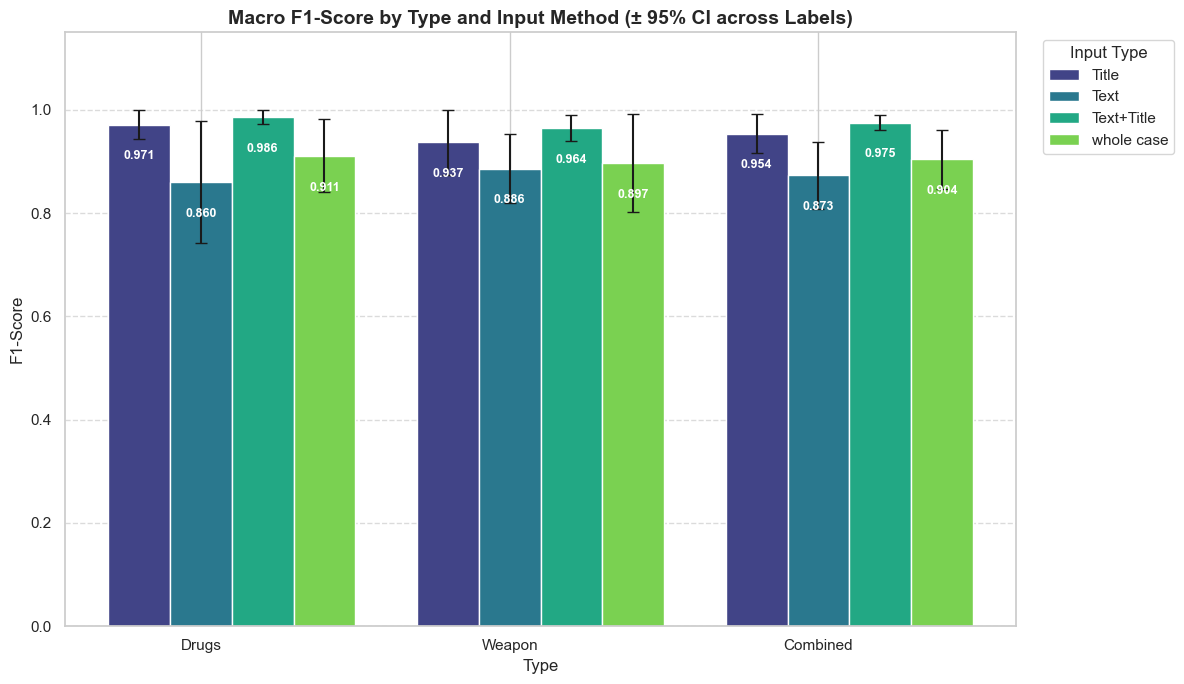

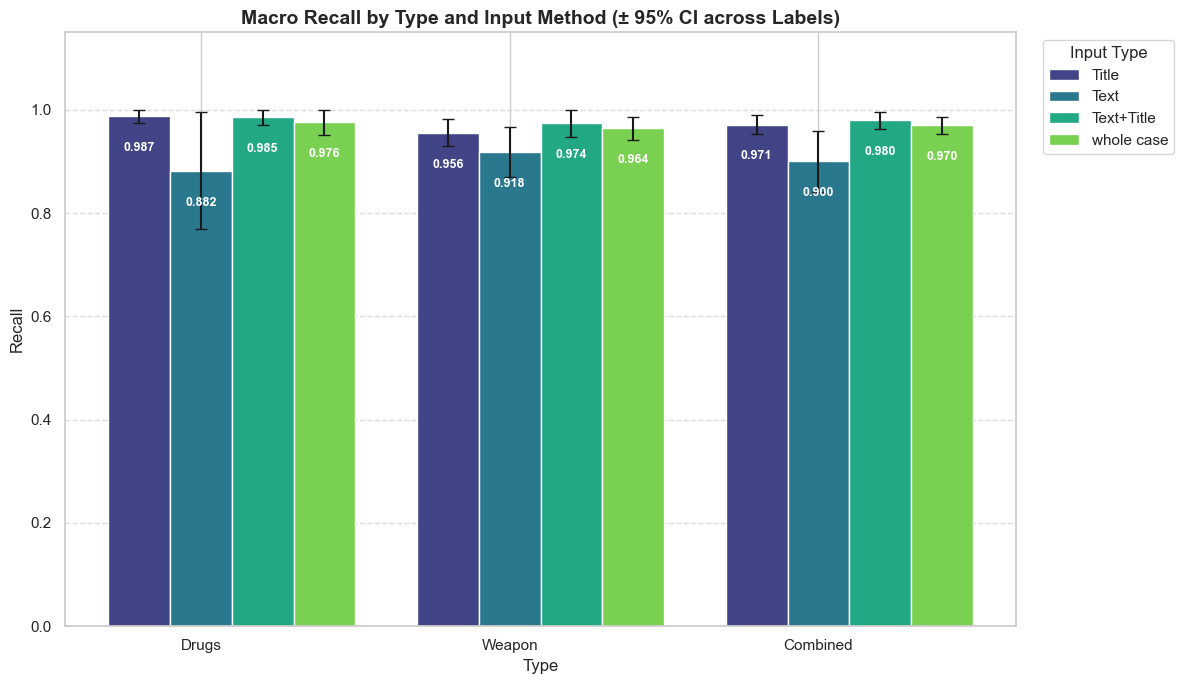

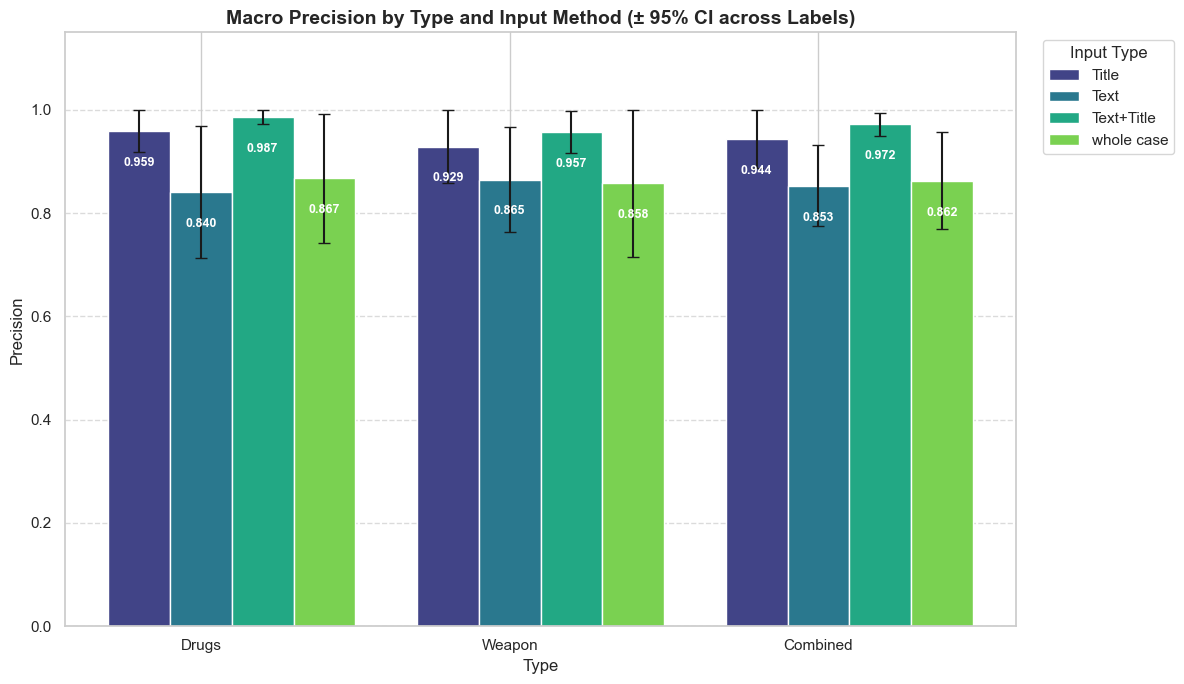

In [31]:
all_metrics = []

# Z-score for 95% CI
Z_95 = 1.96

def clip_ci(mean_val, ci_val):
    """Clip CI so that mean + ci <= 1 and mean - ci >= 0"""
    upper_limit = 1.0 - mean_val
    lower_limit = mean_val
    return min(ci_val, upper_limit, lower_limit)

for TYPE in TYPES:
    results_df = pd.read_csv(os.path.join(RESULTS_PATH,TYPE, 'all_results.csv'))
    prediction_columns = ['title_results', 'text_results', 'text_and_title_results', 'whole_case_results']
    ground_truth_column = 'label'
    
    results_df = results_df.dropna(subset=[ground_truth_column])
    results_df[prediction_columns] = results_df[prediction_columns].fillna('MISSING')
    results_df[ground_truth_column] = results_df[ground_truth_column].astype(str)
    for col in prediction_columns:
        results_df[col] = results_df[col].astype(str)
    
    unique_labels = sorted(results_df[ground_truth_column].unique())
    
    for col in prediction_columns:
        y_true = results_df[ground_truth_column]
        y_pred = results_df[col]
        
        for label in unique_labels:
            label_precision = precision_score(y_true, y_pred, labels=[label], average='micro', zero_division=0)
            label_recall = recall_score(y_true, y_pred, labels=[label], average='micro', zero_division=0)
            label_f1 = f1_score(y_true, y_pred, labels=[label], average='micro', zero_division=0)
            
            # Map input type to Hebrew-friendly names
            input_name = {'title_results': 'Title', 'text_results': 'Text', 'text_and_title_results': 'Text+Title', 'whole_case_results': 'whole case'}[col]
            
            all_metrics.append({
                'Type': TYPE.capitalize(),
                'Label': label,
                'Label_Display': get_display(label),
                'Input_Type': input_name,
                'Precision': label_precision,
                'Recall': label_recall,
                'F1-Score': label_f1
            })

metrics_df = pd.DataFrame(all_metrics)

# Calculate overall metrics per Type and Input_Type (mean and 95% CI across all labels)
overall_metrics = metrics_df.groupby(['Type', 'Input_Type']).agg({
    'Precision': ['mean', 'std', 'count'],
    'Recall': ['mean', 'std', 'count'],
    'F1-Score': ['mean', 'std', 'count']
}).reset_index()
overall_metrics.columns = ['Type', 'Input_Type', 
                           'Precision_mean', 'Precision_std', 'Precision_n',
                           'Recall_mean', 'Recall_std', 'Recall_n', 
                           'F1-Score_mean', 'F1-Score_std', 'F1-Score_n']

# Calculate 95% CI
overall_metrics['Precision_ci'] = Z_95 * overall_metrics['Precision_std'] / np.sqrt(overall_metrics['Precision_n'].replace(0, 1))
overall_metrics['Recall_ci'] = Z_95 * overall_metrics['Recall_std'] / np.sqrt(overall_metrics['Recall_n'].replace(0, 1))
overall_metrics['F1-Score_ci'] = Z_95 * overall_metrics['F1-Score_std'] / np.sqrt(overall_metrics['F1-Score_n'].replace(0, 1))

# Add Combined (average of drugs and weapon) with 95% CI
combined_metrics = metrics_df.groupby('Input_Type').agg({
    'Precision': ['mean', 'std', 'count'],
    'Recall': ['mean', 'std', 'count'],
    'F1-Score': ['mean', 'std', 'count']
}).reset_index()
combined_metrics.columns = ['Input_Type', 
                            'Precision_mean', 'Precision_std', 'Precision_n',
                            'Recall_mean', 'Recall_std', 'Recall_n', 
                            'F1-Score_mean', 'F1-Score_std', 'F1-Score_n']
combined_metrics['Type'] = 'Combined'

# Calculate 95% CI for combined
combined_metrics['Precision_ci'] = Z_95 * combined_metrics['Precision_std'] / np.sqrt(combined_metrics['Precision_n'].replace(0, 1))
combined_metrics['Recall_ci'] = Z_95 * combined_metrics['Recall_std'] / np.sqrt(combined_metrics['Recall_n'].replace(0, 1))
combined_metrics['F1-Score_ci'] = Z_95 * combined_metrics['F1-Score_std'] / np.sqrt(combined_metrics['F1-Score_n'].replace(0, 1))

overall_metrics = pd.concat([overall_metrics, combined_metrics], ignore_index=True)

# Fill NaN with 0
overall_metrics = overall_metrics.fillna(0)

metrics_to_plot = [('F1-Score', 'F1-Score'), ('Recall', 'Recall'), ('Precision', 'Precision')]

# =====================
# 3 Graphs: Types on X-axis, Input Types as legend, with 95% CI error bars
# =====================
for metric_col, metric_name in metrics_to_plot:
    plt.figure(figsize=(12, 7))
    
    # Prepare data for plotting with error bars
    type_order = ['Drugs', 'Weapon', 'Combined']
    input_order = ['Title', 'Text', 'Text+Title', 'whole case']
    x = np.arange(len(type_order))
    width = 0.2
    
    colors = sns.color_palette('viridis', 4)
    
    for i, input_type in enumerate(input_order):
        means = []
        cis = []
        for t in type_order:
            row = overall_metrics[(overall_metrics['Type'] == t) & (overall_metrics['Input_Type'] == input_type)]
            mean_val = row[f'{metric_col}_mean'].values[0] if len(row) > 0 else 0
            ci_val = row[f'{metric_col}_ci'].values[0] if len(row) > 0 else 0
            means.append(mean_val)
            # Clip CI so error bars don't exceed [0, 1]
            cis.append(clip_ci(mean_val, ci_val))
        
        bars = plt.bar(x + i * width, means, width, label=input_type, color=colors[i], 
                       yerr=cis, capsize=4, error_kw={'linewidth': 1.5})
        
        # Add value labels inside bars
        for j, (bar, mean_val) in enumerate(zip(bars, means)):
            if mean_val > 0.15:
                plt.annotate(f'{mean_val:.3f}', (bar.get_x() + bar.get_width()/2., mean_val - 0.05),
                            ha='center', va='top', fontsize=9, fontweight='bold', color='white')
            else:
                plt.annotate(f'{mean_val:.3f}', (bar.get_x() + bar.get_width()/2., mean_val + cis[j] + 0.02),
                            ha='center', va='bottom', fontsize=9, fontweight='bold', color='black')
    
    plt.xlabel('Type', fontsize=12)
    plt.ylabel(metric_name, fontsize=12)
    plt.title(f'Macro {metric_name} by Type and Input Method (± 95% CI across Labels)', fontsize=14, fontweight='bold')
    plt.xticks(x + width, type_order)
    plt.ylim(0, 1.15)
    plt.legend(title='Input Type', bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

## Micro Comparison

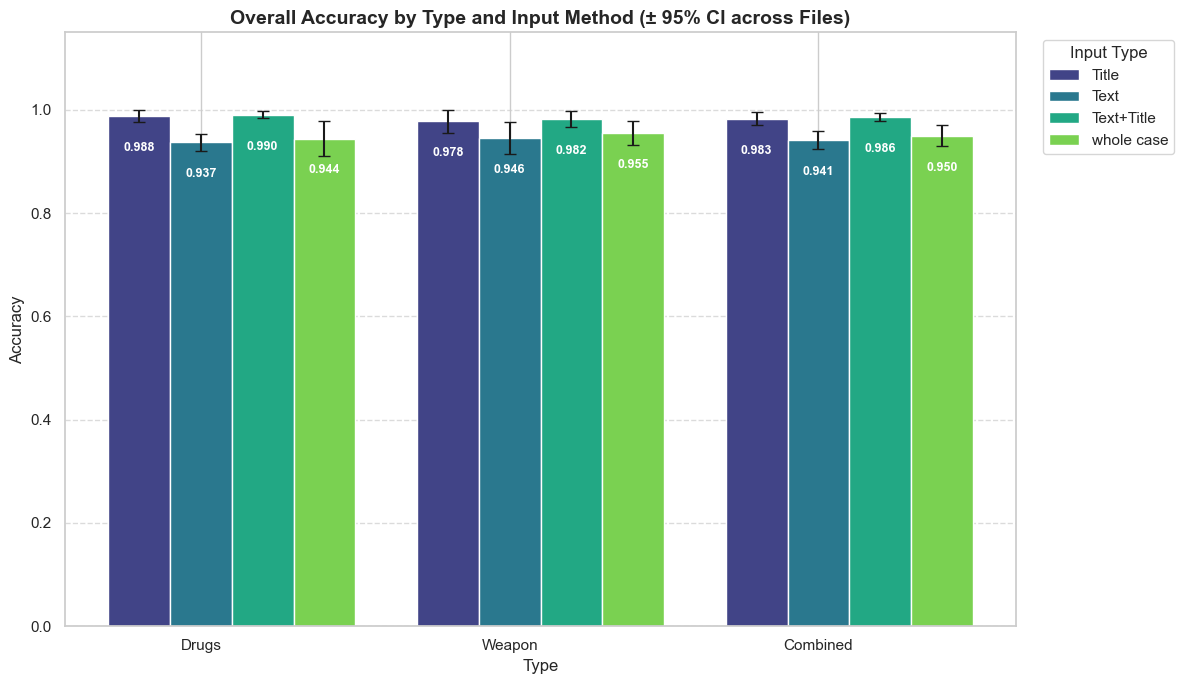

In [50]:
accuracy_data = []

# Z-score for 95% CI
Z_95 = 1.96

def clip_ci(mean_val, ci_val):
    """Clip CI so that mean + ci <= 1 and mean - ci >= 0"""
    upper_limit = 1.0 - mean_val
    lower_limit = mean_val
    return min(ci_val, upper_limit, lower_limit)

for TYPE in TYPES:
    results_df = pd.read_csv(os.path.join(RESULTS_PATH,TYPE, 'all_results.csv'))
    prediction_columns = ['title_results', 'text_results', 'text_and_title_results', 'whole_case_results']
    ground_truth_column = 'label'
    
    results_df = results_df.dropna(subset=[ground_truth_column])
    results_df[prediction_columns] = results_df[prediction_columns].fillna('MISSING')
    results_df[ground_truth_column] = results_df[ground_truth_column].astype(str)
    for col in prediction_columns:
        results_df[col] = results_df[col].astype(str)
    
    # Get file info to calculate per-file accuracy for CI
    path = os.path.join(RESULTS_PATH, TYPE, "only_title")
    files = [f for f in os.listdir(path) if f.endswith('.csv')]
    
    for col in prediction_columns:
        y_true = results_df[ground_truth_column]
        y_pred = results_df[col]
        
        # Calculate OVERALL accuracy
        overall_acc = accuracy_score(y_true, y_pred)
        
        # Calculate per-file accuracies for error bars
        file_accuracies = []
        start_idx = 0
        case_map = {'title_results': 'only_title', 'text_results': 'only_text', 'text_and_title_results': 'text_and_title', 'whole_case_results': 'whole_case'}
        case = case_map[col]
        for file in files:
            file_path = os.path.join(RESULTS_PATH, TYPE, case, file)
            if os.path.exists(file_path):
                file_df = pd.read_csv(file_path)
                file_len = len(file_df)
                if file_len > 0:
                    file_y_true = y_true.iloc[start_idx:start_idx + file_len]
                    file_y_pred = y_pred.iloc[start_idx:start_idx + file_len]
                    if len(file_y_true) > 0:
                        file_acc = accuracy_score(file_y_true, file_y_pred)
                        file_accuracies.append(file_acc)
                start_idx += file_len
        # Calculate 95% CI
        n = len(file_accuracies)
        acc_std = np.std(file_accuracies) if n > 1 else 0
        acc_ci = Z_95 * acc_std / np.sqrt(n) if n > 0 else 0
        
        input_name = {'title_results': 'Title', 'text_results': 'Text', 'text_and_title_results': 'Text+Title', 'whole_case_results': 'whole case'}[col]
        
        accuracy_data.append({
            'Type': TYPE.capitalize(),
            'Input_Type': input_name,
            'Accuracy_mean': overall_acc,
            'Accuracy_std': acc_std,
            'Accuracy_n': n,
            'Accuracy_ci': acc_ci
        })

accuracy_df = pd.DataFrame(accuracy_data)
# Add Combined (average of drugs and weapon) with 95% CI
combined_acc = accuracy_df.groupby('Input_Type').agg({
    'Accuracy_mean': 'mean',
    'Accuracy_std': 'mean',
    'Accuracy_n': 'sum'
}).reset_index()
combined_acc['Accuracy_ci'] = Z_95 * combined_acc['Accuracy_std'] / np.sqrt(combined_acc['Accuracy_n'].replace(0, 1))
combined_acc['Type'] = 'Combined'
accuracy_df = pd.concat([accuracy_df, combined_acc], ignore_index=True)

# =====================
# Single plot: Types on X-axis, Input Types as legend, with 95% CI error bars
# =====================
plt.figure(figsize=(12, 7))

type_order = ['Drugs', 'Weapon', 'Combined']
input_order = ['Title', 'Text', 'Text+Title', 'whole case']
x = np.arange(len(type_order))
width = 0.2

colors = sns.color_palette('viridis', 4)

for i, input_type in enumerate(input_order):
    means = []
    cis = []
    for t in type_order:
        row = accuracy_df[(accuracy_df['Type'] == t) & (accuracy_df['Input_Type'] == input_type)]
        mean_val = row['Accuracy_mean'].values[0] if len(row) > 0 else 0
        ci_val = row['Accuracy_ci'].values[0] if len(row) > 0 else 0
        means.append(mean_val)
        # Clip CI so error bars don't exceed [0, 1]
        cis.append(clip_ci(mean_val, ci_val))
    
    bars = plt.bar(x + i * width, means, width, label=input_type, color=colors[i],
                   yerr=cis, capsize=4, error_kw={'linewidth': 1.5})
    
    # Add value labels
    for j, (bar, mean_val) in enumerate(zip(bars, means)):
        if mean_val > 0.15:
            plt.annotate(f'{mean_val:.3f}', (bar.get_x() + bar.get_width()/2., mean_val - 0.05),
                        ha='center', va='top', fontsize=9, fontweight='bold', color='white')
        else:
            plt.annotate(f'{mean_val:.3f}', (bar.get_x() + bar.get_width()/2., mean_val + cis[j] + 0.02),
                        ha='center', va='bottom', fontsize=9, fontweight='bold', color='black')

plt.xlabel('Type', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Overall Accuracy by Type and Input Method (± 95% CI across Files)', fontsize=14, fontweight='bold')
plt.xticks(x + width, type_order)
plt.ylim(0, 1.15)
plt.legend(title='Input Type', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Save csv of results

In [ ]:
all_stats = []
combined_results = {}  # Store for combined calculation

for TYPE in TYPES:
    results_df = pd.read_csv(os.path.join(RESULTS_PATH,TYPE, 'all_results.csv'))
    prediction_columns = ['title_results', 'text_results', 'text_and_title_results', 'whole_case_results']
    ground_truth_column = 'label'
    
    results_df = results_df.dropna(subset=[ground_truth_column])
    results_df[prediction_columns] = results_df[prediction_columns].fillna('MISSING')
    results_df[ground_truth_column] = results_df[ground_truth_column].astype(str)
    for col in prediction_columns:
        results_df[col] = results_df[col].astype(str)
    
    # Store for combined
    combined_results[TYPE] = results_df.copy()
    
    unique_labels = sorted(results_df[ground_truth_column].unique())
    
    for col in prediction_columns:
        y_true = results_df[ground_truth_column]
        y_pred = results_df[col]
        
        # Overall metrics
        acc = accuracy_score(y_true, y_pred)
        macro_precision = precision_score(y_true, y_pred, average='macro', zero_division=0)
        macro_recall = recall_score(y_true, y_pred, average='macro', zero_division=0)
        macro_f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
        micro_f1 = f1_score(y_true, y_pred, average='micro', zero_division=0)
        weighted_f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
        
        input_name = {'title_results': 'Title', 'text_results': 'Text', 'text_and_title_results': 'Text+Title', 'whole_case_results': 'whole case'}[col]
        
        # Add overall row
        all_stats.append({
            'Dataset': TYPE.capitalize(),
            'Input_Type': input_name,
            'Label': 'OVERALL',
            'Accuracy': acc,
            'Precision': macro_precision,
            'Recall': macro_recall,
            'F1-Score': macro_f1,
            'Micro-F1': micro_f1,
            'Weighted-F1': weighted_f1,
            'Support': len(y_true)
        })
        
        # Per-label metrics
        for label in unique_labels:
            label_precision = precision_score(y_true, y_pred, labels=[label], average='micro', zero_division=0)
            label_recall = recall_score(y_true, y_pred, labels=[label], average='micro', zero_division=0)
            label_f1 = f1_score(y_true, y_pred, labels=[label], average='micro', zero_division=0)
            support = (y_true == label).sum()
            
            all_stats.append({
                'Dataset': TYPE.capitalize(),
                'Input_Type': input_name,
                'Label': label,
                'Accuracy': None,
                'Precision': label_precision,
                'Recall': label_recall,
                'F1-Score': label_f1,
                'Micro-F1': None,
                'Weighted-F1': None,
                'Support': support
            })

# =====================
# COMBINED (Drugs + Weapon) Statistics
# =====================
combined_df = pd.concat([combined_results['drugs'], combined_results['weapon']], ignore_index=True)
all_unique_labels = sorted(combined_df['label'].unique())

for col in prediction_columns:
    y_true = combined_df['label']
    y_pred = combined_df[col]
    
    # Overall metrics
    acc = accuracy_score(y_true, y_pred)
    macro_precision = precision_score(y_true, y_pred, average='macro', zero_division=0)
    macro_recall = recall_score(y_true, y_pred, average='macro', zero_division=0)
    macro_f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
    micro_f1 = f1_score(y_true, y_pred, average='micro', zero_division=0)
    weighted_f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    
    input_name = {'title_results': 'Title', 'text_results': 'Text', 'text_and_title_results': 'Text+Title', 'whole_case_results': 'whole case'}[col]
    
    # Add overall row for combined
    all_stats.append({
        'Dataset': 'Combined',
        'Input_Type': input_name,
        'Label': 'OVERALL',
        'Accuracy': acc,
        'Precision': macro_precision,
        'Recall': macro_recall,
        'F1-Score': macro_f1,
        'Micro-F1': micro_f1,
        'Weighted-F1': weighted_f1,
        'Support': len(y_true)
    })
    
    # Per-label metrics for combined
    for label in all_unique_labels:
        label_precision = precision_score(y_true, y_pred, labels=[label], average='micro', zero_division=0)
        label_recall = recall_score(y_true, y_pred, labels=[label], average='micro', zero_division=0)
        label_f1 = f1_score(y_true, y_pred, labels=[label], average='micro', zero_division=0)
        support = (y_true == label).sum()
        
        all_stats.append({
            'Dataset': 'Combined',
            'Input_Type': input_name,
            'Label': label,
            'Accuracy': None,
            'Precision': label_precision,
            'Recall': label_recall,
            'F1-Score': label_f1,
            'Micro-F1': None,
            'Weighted-F1': None,
            'Support': support
        })

# Create DataFrame
stats_df = pd.DataFrame(all_stats)

# Reorder columns
stats_df = stats_df[['Dataset', 'Input_Type', 'Label', 'Accuracy', 'Precision', 'Recall', 
                     'F1-Score', 'Micro-F1', 'Weighted-F1', 'Support']]

# Save to CSV
output_path = os.path.join(RESULTS_PATH, 'all_statistics_summary.csv')
stats_df.to_csv(output_path, index=False, encoding='utf-8-sig')
print(f"Statistics saved to: {output_path}")
print(f"Total rows: {len(stats_df)}")

# Display the table
print("\n" + "=" * 100)
print("OVERALL STATISTICS (per Dataset and Input Type)")
print("=" * 100)
overall_stats = stats_df[stats_df['Label'] == 'OVERALL'][['Dataset', 'Input_Type', 'Accuracy', 'Precision', 'Recall', 'F1-Score', 'Support']]
print(overall_stats.to_string(index=False))

# Also create a summary pivot table
print("\n" + "=" * 100)
print("ACCURACY SUMMARY TABLE")
print("=" * 100)
accuracy_pivot = stats_df[stats_df['Label'] == 'OVERALL'].pivot(index='Dataset', columns='Input_Type', values='Accuracy')
accuracy_pivot = accuracy_pivot[['Title', 'Text', 'Text+Title', 'whole case']]
print(accuracy_pivot.round(4))

print("\n" + "=" * 100)
print("F1-SCORE SUMMARY TABLE")
print("=" * 100)
f1_pivot = stats_df[stats_df['Label'] == 'OVERALL'].pivot(index='Dataset', columns='Input_Type', values='F1-Score')
f1_pivot = f1_pivot[['Title', 'Text', 'Text+Title', 'whole case']]
print(f1_pivot.round(4))

# Show full dataframe
stats_df

Statistics saved to: ..\results\all_statistics_summary.csv
Total rows: 63

OVERALL STATISTICS (per Dataset and Input Type)
 Dataset Input_Type  Accuracy  Precision   Recall  F1-Score  Support
   Drugs      Title  0.987534   0.958906 0.987086  0.971257     1845
   Drugs       Text  0.937127   0.840468 0.881821  0.859541     1845
   Drugs Text+Title  0.990244   0.986668 0.985097  0.985707     1845
  Weapon      Title  0.977823   0.928654 0.955644  0.936726     1488
  Weapon       Text  0.945565   0.864991 0.918216  0.886154     1488
  Weapon Text+Title  0.981855   0.956655 0.973994  0.964428     1488
Combined      Title  0.983198   0.944838 0.974394  0.956608     3333
Combined       Text  0.940894   0.851781 0.897080  0.871976     3333
Combined Text+Title  0.986499   0.973397 0.980800  0.977049     3333

ACCURACY SUMMARY TABLE
Input_Type   Title    Text  Text+Title
Dataset                               
Combined    0.9832  0.9409      0.9865
Drugs       0.9875  0.9371      0.9902
Weapon 

,Dataset,Input_Type,Label,Accuracy,Precision,Recall,F1-Score,Micro-F1,Weighted-F1,Support
0,Drugs,Title,OVERALL,0.987534,0.958906,0.987086,0.971257,0.987534,0.987787,1845
1,Drugs,Title,דיון והכרעה,NaN,1.000000,0.995331,0.997660,NaN,NaN,1071
2,Drugs,Title,טיעוני הצדדים,NaN,1.000000,0.938017,0.968017,NaN,NaN,242
3,Drugs,Title,מידע אחר,NaN,0.958904,1.000000,0.979021,NaN,NaN,70
4,Drugs,Title,עובדות המקרה,NaN,0.975089,0.989170,0.982079,NaN,NaN,277
...,...,...,...,...,...,...,...,...,...,...
58,Combined,Text+Title,טיעוני הצדדים,NaN,0.977876,0.977876,0.977876,NaN,NaN,452
59,Combined,Text+Title,מידע אחר,NaN,1.000000,1.000000,1.000000,NaN,NaN,116
60,Combined,Text+Title,עובדות המקרה,NaN,0.963134,0.965358,0.964245,NaN,NaN,433
61,Combined,Text+Title,ראיות לעונש,NaN,0.930000,0.948980,0.939394,NaN,NaN,98


In [112]:
# Add this as a new cell after "## Save csv of results"

from sklearn.metrics import classification_report

# =====================
# Classification Reports
# =====================
print("=" * 100)
print("CLASSIFICATION REPORTS")
print("=" * 100)

for TYPE in TYPES:
    results_df = pd.read_csv(os.path.join(RESULTS_PATH,TYPE, 'all_results.csv'))
    prediction_columns = ['title_results', 'text_results', 'text_and_title_results']
    ground_truth_column = 'label'
    
    results_df = results_df.dropna(subset=[ground_truth_column])
    results_df[prediction_columns] = results_df[prediction_columns].fillna('MISSING')
    results_df[ground_truth_column] = results_df[ground_truth_column].astype(str)
    for col in prediction_columns:
        results_df[col] = results_df[col].astype(str)
    
    unique_labels = sorted(results_df[ground_truth_column].unique())
    
    print(f"\n{'='*50}")
    print(f"DATASET: {TYPE.upper()}")
    print(f"{'='*50}")
    
    for col in prediction_columns:
        input_name = {'title_results': 'Title', 'text_results': 'Text', 'text_and_title_results': 'Text+Title'}[col]
        y_true = results_df[ground_truth_column]
        y_pred = results_df[col]
        
        print(f"\n--- Input Type: {input_name} ---")
        print(classification_report(y_true, y_pred, labels=unique_labels, zero_division=0))

# =====================
# Combined Classification Report
# =====================
print(f"\n{'='*50}")
print("DATASET: COMBINED (Drugs + Weapon)")
print(f"{'='*50}")

combined_df = pd.concat([
    pd.read_csv(os.path.join(RESULTS_PATH,t, 'all_results.csv')) for t in TYPES
], ignore_index=True)

combined_df = combined_df.dropna(subset=['label'])
combined_df[prediction_columns] = combined_df[prediction_columns].fillna('MISSING')
combined_df['label'] = combined_df['label'].astype(str)
for col in prediction_columns:
    combined_df[col] = combined_df[col].astype(str)

all_unique_labels = sorted(combined_df['label'].unique())

for col in prediction_columns:
    input_name = {'title_results': 'Title', 'text_results': 'Text', 'text_and_title_results': 'Text+Title'}[col]
    y_true = combined_df['label']
    y_pred = combined_df[col]
    
    print(f"\n--- Input Type: {input_name} ---")
    print(classification_report(y_true, y_pred, labels=all_unique_labels, zero_division=0))

# =====================
# Save Classification Reports to CSV
# =====================
all_reports = []

for TYPE in TYPES + ['combined']:
    if TYPE == 'combined':
        df = combined_df
        labels = all_unique_labels
    else:
        df = pd.read_csv(os.path.join(RESULTS_PATH,TYPE, 'all_results.csv'))
        df = df.dropna(subset=['label'])
        df[prediction_columns] = df[prediction_columns].fillna('MISSING')
        df['label'] = df['label'].astype(str)
        for col in prediction_columns:
            df[col] = df[col].astype(str)
        labels = sorted(df['label'].unique())
    
    for col in prediction_columns:
        input_name = {'title_results': 'Title', 'text_results': 'Text', 'text_and_title_results': 'Text+Title'}[col]
        y_true = df['label']
        y_pred = df[col]
        
        report_dict = classification_report(y_true, y_pred, labels=labels, 
                                            output_dict=True, zero_division=0)
        
        for label, metrics in report_dict.items():
            if isinstance(metrics, dict):
                all_reports.append({
                    'Dataset': TYPE.capitalize(),
                    'Input_Type': input_name,
                    'Label': label,
                    'Precision': metrics.get('precision', None),
                    'Recall': metrics.get('recall', None),
                    'F1-Score': metrics.get('f1-score', None),
                    'Support': metrics.get('support', None)
                })

reports_df = pd.DataFrame(all_reports)
reports_path = os.path.join(RESULTS_PATH, 'classification_reports.csv')
reports_df.to_csv(reports_path, index=False, encoding='utf-8-sig')
print(f"\n✅ Classification reports saved to: {reports_path}")

CLASSIFICATION REPORTS

DATASET: DRUGS

--- Input Type: Title ---
                  precision    recall  f1-score   support

     דיון והכרעה       1.00      1.00      1.00      1071
   טיעוני הצדדים       1.00      0.94      0.97       242
        מידע אחר       0.96      1.00      0.98        70
    עובדות המקרה       0.98      0.99      0.98       277
     ראיות לעונש       0.82      1.00      0.90        59
תסקיר שירות מבחן       1.00      1.00      1.00       126

        accuracy                           0.99      1845
       macro avg       0.96      0.99      0.97      1845
    weighted avg       0.99      0.99      0.99      1845


--- Input Type: Text ---
                  precision    recall  f1-score   support

     דיון והכרעה       1.00      0.97      0.98      1071
   טיעוני הצדדים       0.86      0.86      0.86       242
        מידע אחר       0.84      1.00      0.92        70
    עובדות המקרה       0.94      0.94      0.94       277
     ראיות לעונש       0.54      0